In [275]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
import scipy
from scipy.spatial import KDTree
from scipy.spatial import cKDTree
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import math
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from scipy.signal import savgol_filter

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/sanilawijesekara/ricevision-v7/tensorflow2/default/1/ricevision_v7_district_aware.keras
/kaggle/input/models/sanilawijesekara/ricevision-yield/scikitlearn/default/1/yield_scaler.pkl
/kaggle/input/models/sanilawijesekara/ricevision-yield/scikitlearn/default/1/rice_yield_model_final.pkl
/kaggle/input/datasets/sanilawijesekara/ricevision-test-data/inference_v1.csv
/kaggle/input/datasets/sanilawijesekara/sl-baselines/sri_lanka_district_baselines.csv


In [276]:
work_dir = "/kaggle/working"

for filename in os.listdir(work_dir):
    file_path = os.path.join(work_dir, filename)
    if os.path.isfile(file_path) or os.path.islink(file_path):
        os.unlink(file_path)
    elif os.path.isdir(file_path):
        shutil.rmtree(file_path)

print("Output directory cleaned!")

Output directory cleaned!


In [277]:
df = pd.read_csv("/kaggle/input/datasets/sanilawijesekara/ricevision-test-data/inference_v1.csv")
df.head()

,system:index,B1,B11,B12,B2,B3,B4,B5,B6,B7,...,rand,rh_mean,slope,t_day,t_night,timestep,tmax,tmean,tmin,.geo
0,00000000000000000674_0,3784.0,2811.5,2449.5,3341.0,3255.5,3131.0,3646.0,3945.0,4053.0,...,0.051591,79.788370,0.057968,28.215710,27.147144,10,30.819010,27.652771,25.344461,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,00000000000000000674_0,687.5,2136.5,1317.0,679.0,948.5,828.0,1387.5,2853.0,3413.5,...,0.051591,85.437950,0.057968,27.153957,26.062304,9,32.193916,26.572462,24.568750,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,00000000000000000674_0,3724.0,2302.0,1873.0,3593.0,3533.0,3402.0,3436.0,3812.0,3987.5,...,0.051591,82.578255,0.057968,27.754206,26.636936,8,30.693216,27.167702,24.355707,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,00000000000000000674_0,6759.0,4623.5,3906.0,6471.0,6275.5,6117.0,6773.0,6616.0,6528.5,...,0.051591,85.374080,0.057968,26.617165,25.487293,7,30.046412,26.013714,23.961023,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,00000000000000000674_0,315.0,1783.0,1091.0,460.0,698.0,596.0,1159.0,2134.0,2479.0,...,0.051591,83.925840,0.057968,26.182848,24.991013,6,29.747232,25.554018,22.760950,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [278]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47190 entries, 0 to 47189
Data columns (total 36 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   system:index  47190 non-null  object 
 1   B1            47190 non-null  float64
 2   B11           47190 non-null  float64
 3   B12           47190 non-null  float64
 4   B2            47190 non-null  float64
 5   B3            47190 non-null  float64
 6   B4            47190 non-null  float64
 7   B5            47190 non-null  float64
 8   B6            47190 non-null  float64
 9   B7            47190 non-null  float64
 10  B8            47190 non-null  float64
 11  B8A           47190 non-null  float64
 12  B9            47190 non-null  float64
 13  SCL           47190 non-null  float64
 14  cloud_pct     47190 non-null  float64
 15  constant      47190 non-null  int64  
 16  date          47190 non-null  object 
 17  elevation     47190 non-null  float64
 18  lat           47190 non-nu

In [279]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
system:index,47190,4719,000000000000000012d1_0,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B1,47190.0,NaN,NaN,NaN,3493.960829,2398.989771,193.0,1414.5,3077.25,4984.375,19285.0
B11,47190.0,NaN,NaN,NaN,2616.554185,852.372669,174.5,2034.0,2450.0,3040.0,7453.0
B12,47190.0,NaN,NaN,NaN,2075.31566,758.605568,109.0,1538.0,2024.0,2515.0,6589.0
B2,47190.0,NaN,NaN,NaN,3367.120704,2311.547241,219.5,1353.0,2920.0,4804.0,18318.0
B3,47190.0,NaN,NaN,NaN,3351.856209,2147.820561,333.0,1505.0,2898.75,4668.5,15722.0
B4,47190.0,NaN,NaN,NaN,3223.31495,2102.918997,232.0,1511.125,2749.0,4495.5,14544.0
B5,47190.0,NaN,NaN,NaN,3631.322537,2051.514262,316.0,1959.5,3136.5,4843.875,15730.0
B6,47190.0,NaN,NaN,NaN,4168.613795,1769.387325,318.0,2795.0,3750.75,5210.0,14087.0
B7,47190.0,NaN,NaN,NaN,4398.122102,1690.708795,336.0,3130.5,4021.0,5399.0,13308.0


# Drop unnecessary columns

In [280]:
df.drop(columns=['.geo','rand','constant','system:index'], inplace=True)

In [281]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47190 entries, 0 to 47189
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   B1         47190 non-null  float64
 1   B11        47190 non-null  float64
 2   B12        47190 non-null  float64
 3   B2         47190 non-null  float64
 4   B3         47190 non-null  float64
 5   B4         47190 non-null  float64
 6   B5         47190 non-null  float64
 7   B6         47190 non-null  float64
 8   B7         47190 non-null  float64
 9   B8         47190 non-null  float64
 10  B8A        47190 non-null  float64
 11  B9         47190 non-null  float64
 12  SCL        47190 non-null  float64
 13  cloud_pct  47190 non-null  float64
 14  date       47190 non-null  object 
 15  elevation  47190 non-null  float64
 16  lat        47190 non-null  float64
 17  lon        47190 non-null  float64
 18  pixel_id   47190 non-null  int64  
 19  rain_14d   42471 non-null  float64
 20  rain_1

In [282]:
# Calculate counts per pixel
pixel_counts = df.groupby('pixel_id').size().reset_index(name='actual_slots')

# Calculate missing slots
pixel_counts['missing_slots'] = 10 - pixel_counts['actual_slots']

# Filter to see only those with gaps
gaps_df = pixel_counts[pixel_counts['missing_slots'] > 0]

print(f"Total unique pixels: {len(pixel_counts)}")
print(f"Pixels with missing slots: {len(gaps_df)}")
print(gaps_df.head())

Total unique pixels: 4719
Pixels with missing slots: 0
Empty DataFrame
Columns: [pixel_id, actual_slots, missing_slots]
Index: []


# Handle missing values and data cleaning

In [283]:
# Define Column Groups
bands = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12']
weather_cols = ['rain_1d', 'rain_3d', 'rain_7d', 'rain_14d', 'rain_30d', 
                    'tmean', 'tmin', 'tmax', 't_day', 't_night', 'rh_mean']
terrain_cols = ['elevation', 'slope']


In [284]:
def handle_missing_values(df):
    """
    Production-grade cleaning for GEE-exported paddy data with 
    detailed tracking of missing values and cleaning steps.
    """
    print("🚀 Starting Production Data Cleaning Pipeline...")
    

    # --- STEP 0: TYPE ENFORCEMENT & NON-NUMERIC CHECK ---
    print("\n🔍 Checking for non-numeric entries in spectral bands...")
    for col in bands:
        if col in df.columns:
            bad_entries_mask = pd.to_numeric(df[col], errors='coerce').isna() & df[col].notnull()
            if bad_entries_mask.any():
                print(f"   ⚠️ Warning: {col} has {bad_entries_mask.sum()} non-numeric strings.")
                print(f"   Values found: {df.loc[bad_entries_mask, col].unique()}")
            else:
                print(f"   ✅ {col} is already numeric.")
            
            # Force conversion to float32
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('float32')

    if 'SCL' in df.columns:
        print("🏷️ Casting SCL to Category type...")
        df['SCL'] = df['SCL'].astype('category')

    # 1. SETUP: Sort by pixel and time (Oldest to Newest)
    df = df.sort_values(by=['pixel_id', 'timestep'], ascending=[True, False]).copy()

    # --- A. SPATIAL IMPUTATION (Nearest Neighbor) ---
    print("\n📍 Step A: Spatial Imputation (Nearest Neighbor)...")
    initial_nulls = df[weather_cols].isnull().sum().sum()
    if initial_nulls > 0:
        found_spatial = False
        for ts in df['timestep'].unique():
            ts_mask = (df['timestep'] == ts)
            for col in weather_cols:
                if col in df.columns and df.loc[ts_mask, col].isnull().any():
                    valid = df[ts_mask & df[col].notnull()]
                    missing = df[ts_mask & df[col].isnull()]
                    if not valid.empty:
                        tree = KDTree(valid[['lat', 'lon']].values)
                        _, idx = tree.query(missing[['lat', 'lon']].values)
                        df.loc[missing.index, col] = valid.iloc[idx][col].values
                        found_spatial = True
        
        remaining_nulls = df[weather_cols].isnull().sum().sum()
        if found_spatial:
            print(f"   ✅ Fixed {initial_nulls - remaining_nulls} values via nearest neighbor.")
        if remaining_nulls > 0:
            print(f"   ℹ️ {remaining_nulls} weather values still missing (no spatial neighbors available).")
    else:
        print("   ✅ No missing weather values found for spatial imputation.")

    # --- B. TERRAIN (Elevation/Slope) ---
    print("\n⛰️ Step B: Constant Terrain check...")
    existing_terrain = [c for c in terrain_cols if c in df.columns]
    if existing_terrain:
        terrain_nulls = df[existing_terrain].isnull().sum().sum()
        if terrain_nulls > 0:
            df[existing_terrain] = df.groupby('pixel_id')[existing_terrain].ffill().bfill()
            new_nulls = df[existing_terrain].isnull().sum().sum()
            print(f"   ✅ Terrain missing values reduced from {terrain_nulls} to {new_nulls}.")
        else:
            print("   ✅ Terrain data is complete.")

    # --- C. SCL (Categorical Mode) ---
    print("\n🏷️ Step C: SCL Mode Imputation...")
    if 'SCL' in df.columns:
        scl_nulls = df['SCL'].isnull().sum()
        if scl_nulls > 0:
            def get_mode(x):
                m = x.mode()
                return m.iloc[0] if not m.empty else np.nan
            df['SCL'] = df.groupby('pixel_id')['SCL'].transform(lambda x: x.fillna(get_mode(x)))
            print(f"   ✅ Filled {scl_nulls} missing SCL values with pixel mode.")
        else:
            print("   ✅ SCL data is complete.")

    # --- D. CLOUD PERCENTAGE (Mean) ---
    print("\n☁️ Step D: Cloud Pct Mean Imputation...")
    if 'cloud_pct' in df.columns:
        cloud_nulls = df['cloud_pct'].isnull().sum()
        if cloud_nulls > 0:
            df['cloud_pct'] = df.groupby('pixel_id')['cloud_pct'].transform(lambda x: x.fillna(x.mean()))
            print(f"   ✅ Filled {cloud_nulls} cloud values with pixel mean.")
        else:
            print("   ✅ Cloud percentage is complete.")

    # --- E. SPECTRAL BANDS (Linear Interpolation) ---
    print("\n🌈 Step E: Band Interpolation...")
    band_nulls = df[bands].isnull().sum().sum()
    if band_nulls > 0:
        df[bands] = df.groupby('pixel_id', group_keys=False)[bands].apply(
            lambda group: group.interpolate(method='linear', limit_direction='both')
        )
        remaining_band_nulls = df[bands].isnull().sum().sum()
        print(f"   ✅ Band interpolation fixed {band_nulls - remaining_band_nulls} values.")
        if remaining_band_nulls > 0:
            print(f"   ℹ️ {remaining_band_nulls} band values still missing (point has no valid history).")
    else:
        print("   ✅ Spectral bands are complete.")

    # --- F. WEATHER FALLBACK (Temporal ffill) ---
    print("\n☔ Step F: Weather Temporal Fallback (ffill)...")
    existing_weather = [c for c in weather_cols if c in df.columns]
    if existing_weather:
        weather_nulls = df[existing_weather].isnull().sum().sum()
        if weather_nulls > 0:
            df[existing_weather] = df.groupby('pixel_id')[existing_weather].ffill()
            remaining_weather = df[existing_weather].isnull().sum().sum()
            print(f"   ✅ Temporal fallback fixed {weather_nulls - remaining_weather} values (handling CHIRPS lag).")
        else:
            print("   ✅ No weather values remain for temporal fallback.")

    # --- G. DATE RECONSTRUCTION ---
    print("\n📅 Step G: Date formatting and repair...")
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        date_nulls = df['date'].isnull().sum()
        if date_nulls > 0:
            def fix_dates(group):
                if group['date'].isnull().any() and group['date'].notnull().any():
                    v = group[group['date'].notnull()].iloc[0]
                    group['date'] = group.apply(
                        lambda r: v['date'] + pd.Timedelta(days=(v['timestep'] - r['timestep']) * 15), axis=1
                    )
                return group
            df = df.groupby('pixel_id', group_keys=False).apply(fix_dates)
            print(f"   ✅ Repaired {date_nulls} missing dates using 15-day interval logic.")
        else:
            print("   ✅ All dates are present.")

    # --- H. GLOBAL SAFETY NET ---
    print("\n🛡️ Step H: Global Median Fallback...")
    final_nulls = df.isnull().sum().sum()
    if final_nulls > 0:
        print(f"   ⚠️ Warning: {final_nulls} total NaNs still exist in dataset. Applying global median...")
        df = df.fillna(df.median(numeric_only=True))
        df = df.fillna(0) # Final catch-all for remaining non-numeric objects
        print(f"   ✅ All {final_nulls} remaining missing values were zeroed or median-filled.")
    else:
        print("   ✅ No missing values remain. Dataset is perfectly clean.")
    
    print("\n🏁 Cleaning finished. Dataset ready for Scaling/Inference.")
    return df

# Final execution
df = handle_missing_values(df)
print("\n--- Final Dataset Information ---")
df.info()

🚀 Starting Production Data Cleaning Pipeline...

🔍 Checking for non-numeric entries in spectral bands...
   ✅ B1 is already numeric.
   ✅ B2 is already numeric.
   ✅ B3 is already numeric.
   ✅ B4 is already numeric.
   ✅ B5 is already numeric.
   ✅ B6 is already numeric.
   ✅ B7 is already numeric.
   ✅ B8 is already numeric.
   ✅ B8A is already numeric.
   ✅ B9 is already numeric.
   ✅ B11 is already numeric.
   ✅ B12 is already numeric.
🏷️ Casting SCL to Category type...

📍 Step A: Spatial Imputation (Nearest Neighbor)...
   ℹ️ 33033 weather values still missing (no spatial neighbors available).

⛰️ Step B: Constant Terrain check...
   ✅ Terrain data is complete.

🏷️ Step C: SCL Mode Imputation...
   ✅ SCL data is complete.

☁️ Step D: Cloud Pct Mean Imputation...
   ✅ Cloud percentage is complete.

🌈 Step E: Band Interpolation...
   ✅ Spectral bands are complete.

☔ Step F: Weather Temporal Fallback (ffill)...
   ✅ Temporal fallback fixed 33033 values (handling CHIRPS lag).

📅 Step

In [285]:
df.head()

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,...,rain_3d,rain_7d,rh_mean,slope,t_day,t_night,timestep,tmax,tmean,tmin
0,3784.0,2811.5,2449.5,3341.0,3255.5,3131.0,3646.0,3945.0,4053.0,3976.5,...,15.133741,38.909210,79.788370,0.057968,28.215710,27.147144,10,30.819010,27.652771,25.344461
1,687.5,2136.5,1317.0,679.0,948.5,828.0,1387.5,2853.0,3413.5,3357.0,...,81.067680,161.307920,85.437950,0.057968,27.153957,26.062304,9,32.193916,26.572462,24.568750
2,3724.0,2302.0,1873.0,3593.0,3533.0,3402.0,3436.0,3812.0,3987.5,4071.5,...,16.235073,24.352610,82.578255,0.057968,27.754206,26.636936,8,30.693216,27.167702,24.355707
3,6759.0,4623.5,3906.0,6471.0,6275.5,6117.0,6773.0,6616.0,6528.5,6449.5,...,81.239365,121.530174,85.374080,0.057968,26.617165,25.487293,7,30.046412,26.013714,23.961023
4,315.0,1783.0,1091.0,460.0,698.0,596.0,1159.0,2134.0,2479.0,2444.0,...,0.000000,8.172725,83.925840,0.057968,26.182848,24.991013,6,29.747232,25.554018,22.760950


# EDA

In [286]:
for col in df.columns:
    print(col)
    print(df[col].unique())

B1
[3784.   687.5 3724.  ...  357.5 7561.  9188. ]
B11
[2811.5 2136.5 2302.  ...  837.  4657.5 4780. ]
B12
[2449.5 1317.  1873.  ... 3636.5 3930.  4221. ]
B2
[3341.   679.  3593.  ... 1555.5 9057.  1775. ]
B3
[3255.5  948.5 3533.  ...  717.5 9094.   600.5]
B4
[3131.   828.  3402.  ... 9211.  2869.5 7106. ]
B5
[3646.  1387.5 3436.  ... 7068.  3508.5 2748. ]
B6
[3945. 2853. 3812. ... 1324. 1116. 1321.]
B7
[4053.  3413.5 3987.5 ... 1982.5 1979.  2298.5]
B8
[3976.5 3357.  4071.5 ... 2008.5 1625.  7046. ]
B8A
[4142.  3671.5 4116.  ... 9634.  1316.  7209. ]
B9
[ 8334.   3653.5  2735.  ...  1175.   1136.  12506. ]
SCL
[9.0, 6.0, 4.0, 7.0, 5.0, ..., 7.5, 4.5, 3.5, 3.0, 10.0]
Length: 15
Categories (15, float64): [3.0, 3.5, 4.0, 4.5, ..., 8.5, 9.0, 9.5, 10.0]
cloud_pct
[49.86985954 76.84716639 63.69567003 78.15525275 57.17406444 67.38372577
 68.47487686 46.77769726 50.33756968 73.80124842]
date
<DatetimeArray>
['2025-10-11 00:00:00', '2025-10-26 00:00:00', '2025-11-10 00:00:00',
 '2025-11-25 00:

In [287]:
print(df["date"].dtype)
print(df["date"].min(), df["date"].max())

datetime64[ns]
2025-10-11 00:00:00 2026-02-23 00:00:00


In [288]:
df.groupby(df['date'].dt.year).count()

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,...,rain_3d,rain_7d,rh_mean,slope,t_day,t_night,timestep,tmax,tmean,tmin
date,,,,,,,,,,,,,,,,,,,,,
2025,28314,28314,28314,28314,28314,28314,28314,28314,28314,28314,...,28314,28314,28314,28314,28314,28314,28314,28314,28314,28314
2026,18876,18876,18876,18876,18876,18876,18876,18876,18876,18876,...,18876,18876,18876,18876,18876,18876,18876,18876,18876,18876


# Visualizing the timesteps

In [289]:
# 1. Get the list of available timesteps for each pixel
available_timesteps = df.groupby('pixel_id')['timestep'].apply(list).reset_index()

# 2. Count how many slots are available vs missing
# Target is 10 timesteps per pixel
available_timesteps['slot_count'] = available_timesteps['timestep'].apply(len)
available_timesteps['missing_slots'] = 10 - available_timesteps['slot_count']

# 3. Identify the specific missing timestep indices
# Assuming timesteps should be from 0 to 9
all_slots = set(range(10))
available_timesteps['missing_indices'] = available_timesteps['timestep'].apply(
    lambda x: list(all_slots - set(x))
)

print(available_timesteps.head())

   pixel_id                         timestep  slot_count  missing_slots  \
0        22  [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]          10              0   
1        24  [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]          10              0   
2        25  [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]          10              0   
3        26  [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]          10              0   
4        27  [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]          10              0   

  missing_indices  
0             [0]  
1             [0]  
2             [0]  
3             [0]  
4             [0]  


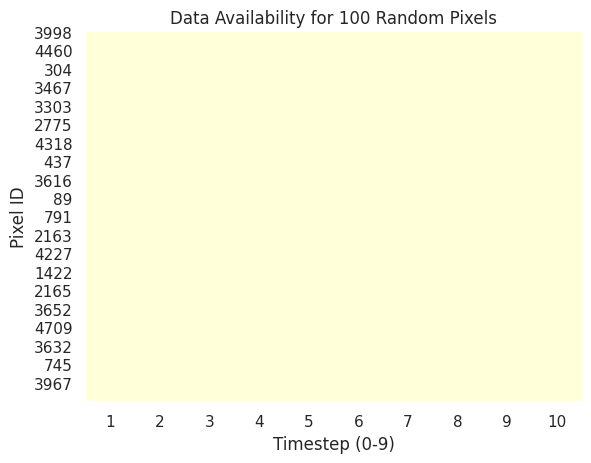

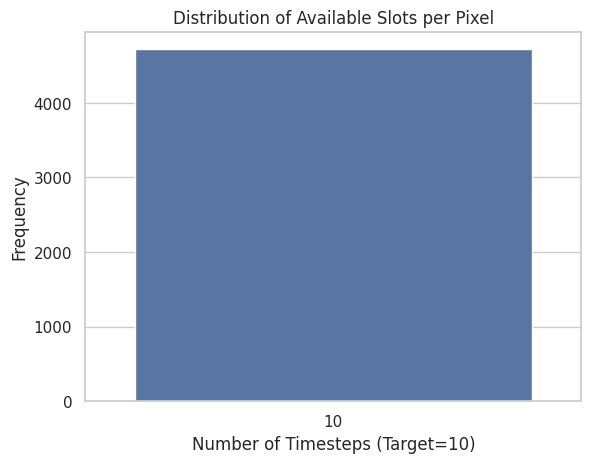

In [290]:
# Create a pivot table for the heatmap
# Fill with 1 where data exists, 0 otherwise
pivot_df = df.pivot_table(index='pixel_id', columns='timestep', values='B1', aggfunc='count').fillna(0)

# If you have too many pixels, you can sample them for the visualization
sample_size = min(100, len(pivot_df))
sns.heatmap(pivot_df.sample(sample_size), cbar=False, cmap="YlGnBu")

plt.title(f'Data Availability for {sample_size} Random Pixels')
plt.xlabel('Timestep (0-9)')
plt.ylabel('Pixel ID')
plt.show()

# 4. Distribution of counts
sns.countplot(data=available_timesteps, x='slot_count')
plt.title('Distribution of Available Slots per Pixel')
plt.xlabel('Number of Timesteps (Target=10)')
plt.ylabel('Frequency')
plt.show()

<Axes: >

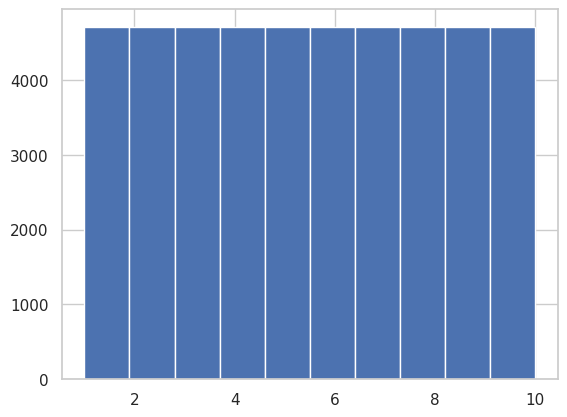

In [291]:
df['timestep'].hist()

**There are exactly 4719 points**

# **Date**

In [292]:
full_dataset = df

In [293]:
full_dataset["date"] = pd.to_datetime(full_dataset["date"], format="%Y-%m-%d")

full_dataset['year'] = full_dataset['date'].dt.year
# Extract month number (1–12)
full_dataset['month'] = full_dataset['date'].dt.month
full_dataset['day'] = full_dataset['date'].dt.day

# Extract month and day as MM-DD format
full_dataset['month_day'] = full_dataset['date'].dt.strftime('%m-%d')

In [294]:
full_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47190 entries, 0 to 47189
Data columns (total 36 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   B1         47190 non-null  float32       
 1   B11        47190 non-null  float32       
 2   B12        47190 non-null  float32       
 3   B2         47190 non-null  float32       
 4   B3         47190 non-null  float32       
 5   B4         47190 non-null  float32       
 6   B5         47190 non-null  float32       
 7   B6         47190 non-null  float32       
 8   B7         47190 non-null  float32       
 9   B8         47190 non-null  float32       
 10  B8A        47190 non-null  float32       
 11  B9         47190 non-null  float32       
 12  SCL        47190 non-null  category      
 13  cloud_pct  47190 non-null  float64       
 14  date       47190 non-null  datetime64[ns]
 15  elevation  47190 non-null  float64       
 16  lat        47190 non-null  float64      

In [295]:
full_dataset.groupby(full_dataset['date'].dt.year).count()

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,...,t_day,t_night,timestep,tmax,tmean,tmin,year,month,day,month_day
date,,,,,,,,,,,,,,,,,,,,,
2025,28314,28314,28314,28314,28314,28314,28314,28314,28314,28314,...,28314,28314,28314,28314,28314,28314,28314,28314,28314,28314
2026,18876,18876,18876,18876,18876,18876,18876,18876,18876,18876,...,18876,18876,18876,18876,18876,18876,18876,18876,18876,18876


In [296]:
year_counts = full_dataset['year'].value_counts().sort_index()
print(year_counts)

year
2025    28314
2026    18876
Name: count, dtype: int64


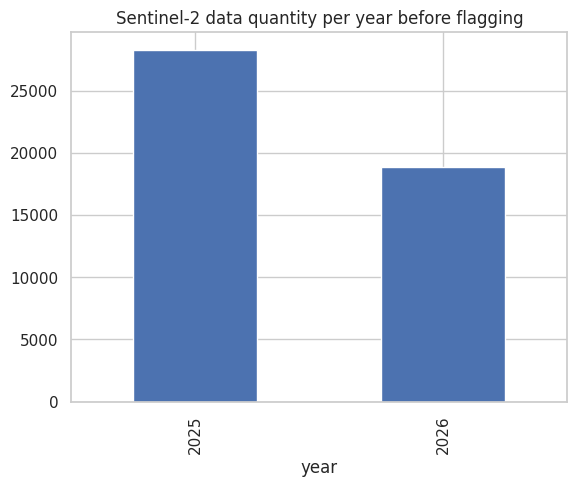

In [297]:
ax = year_counts.plot(kind='bar')
plt.title("Sentinel-2 data quantity per year before flagging")

fig = ax.get_figure()   # extract the Figure from the Axes
fig.savefig("sentinel2yearly_before_flagging.png", dpi=300, bbox_inches='tight')

plt.show()

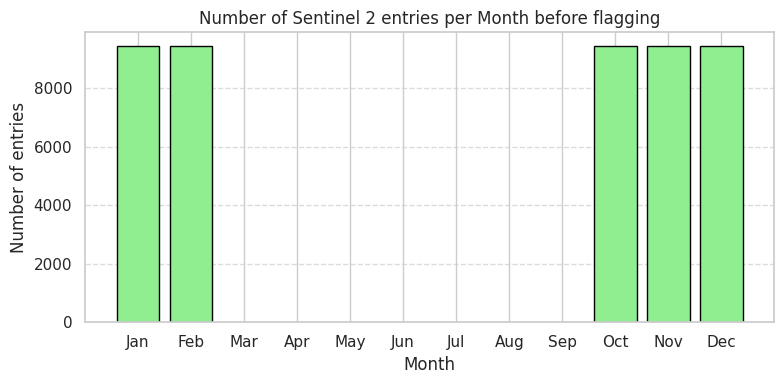

In [298]:
plt.figure(figsize=(8,4))
month_counts = full_dataset['month'].value_counts().sort_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.bar(month_counts.index, month_counts.values, color='lightgreen', edgecolor='black')
plt.xticks(ticks=range(1,13), labels=month_labels)
plt.title('Number of Sentinel 2 entries per Month before flagging')
plt.xlabel('Month')
plt.ylabel('Number of entries')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

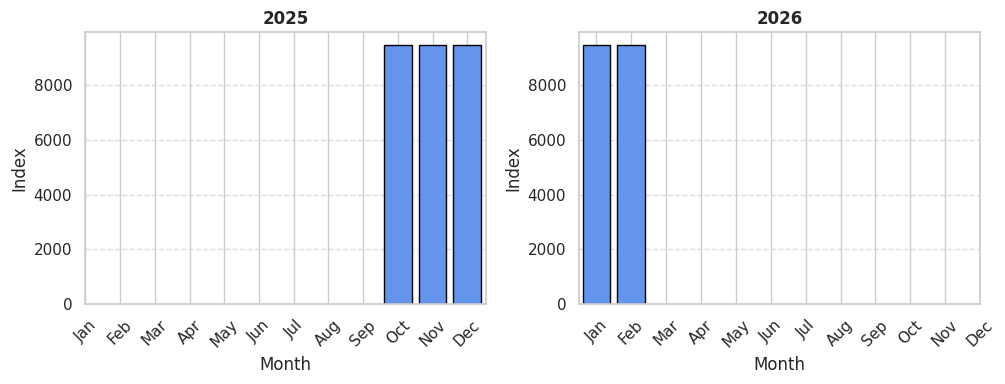

In [299]:
# Unique years sorted
years = sorted(full_dataset['year'].unique())
n_years = len(years)

# Compute grid size for subplots
cols = 3   # you can change to 2 or 4 depending on your preference
rows = math.ceil(n_years / cols)

# Prepare figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()  # flatten in case of 2D grid
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Plot each year
for i, year in enumerate(years):
    ax = axes[i]
    year_df = full_dataset[full_dataset['year'] == year]
    month_counts = year_df['month'].value_counts().sort_index()
    
    ax.bar(month_counts.index, month_counts.values, color='cornflowerblue', edgecolor='black')
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(month_labels, rotation=45)
    ax.set_title(f'{year}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Index')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Hide empty subplots (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()
fig.savefig("plot1.png", dpi=300, bbox_inches='tight')

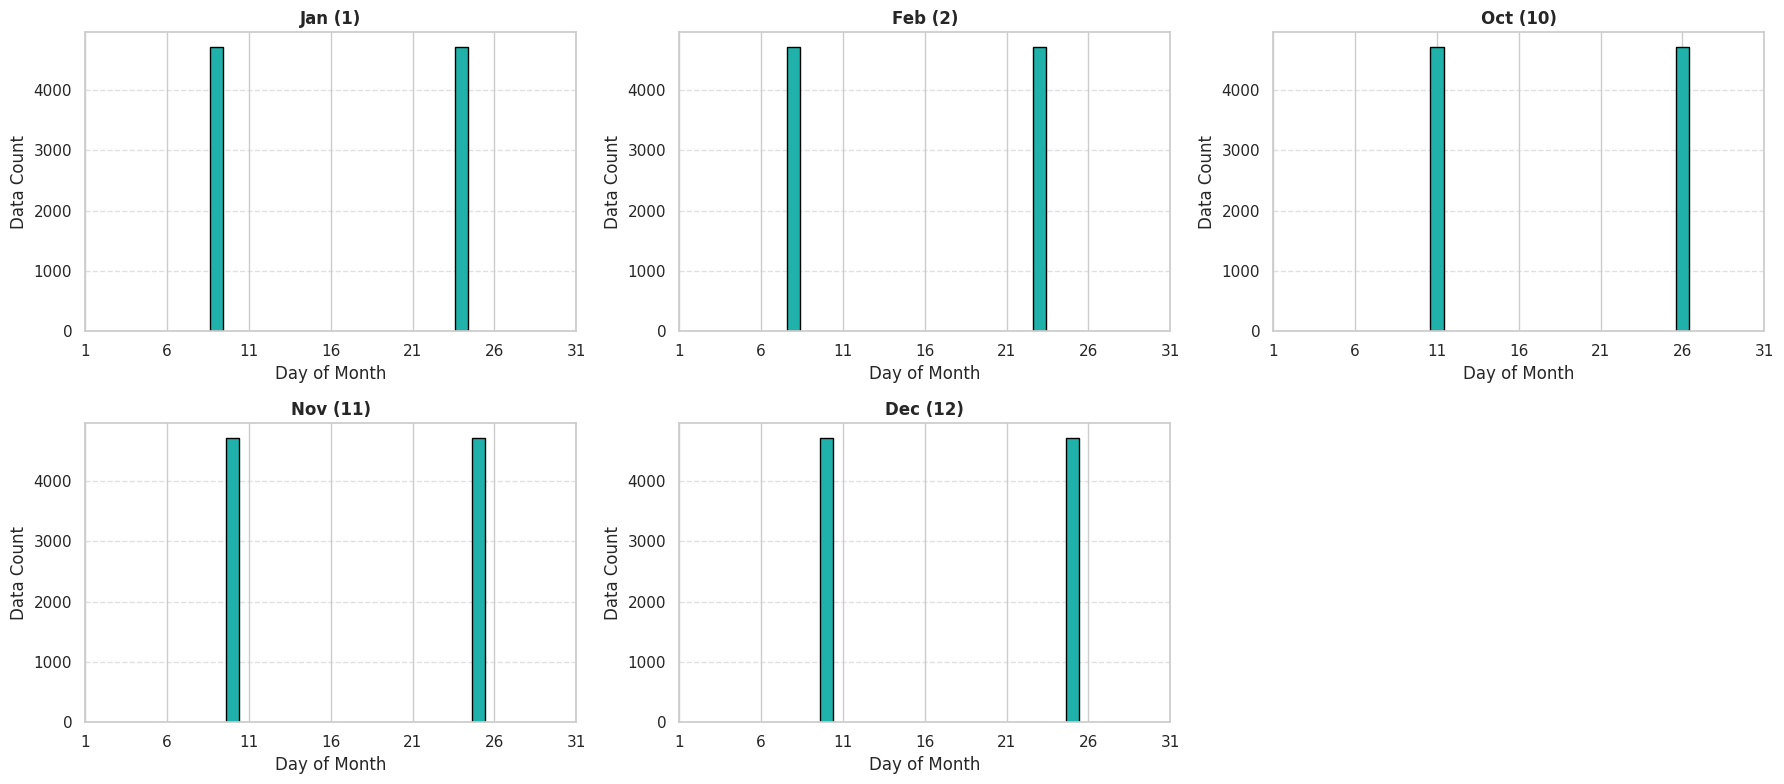

In [300]:
# -----------------------------
# Plot distribution per month
# -----------------------------
months = sorted(full_dataset['month'].dropna().unique())
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

cols = 3
rows = math.ceil(len(months) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()

for i, month in enumerate(months):
    ax = axes[i]
    month_df = full_dataset[full_dataset['month'] == month]
    day_counts = month_df['day'].value_counts().sort_index()
    
    ax.bar(day_counts.index, day_counts.values, color='lightseagreen', edgecolor='black')
    ax.set_title(f'{month_labels[month-1]} ({month})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Day of Month')
    ax.set_ylabel('Data Count')
    ax.set_xticks(range(1, 32, 5))
    ax.grid(axis='y', linestyle='--', alpha=0.6)

# Hide any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
fig.savefig("plot2.png", dpi=300, bbox_inches='tight')

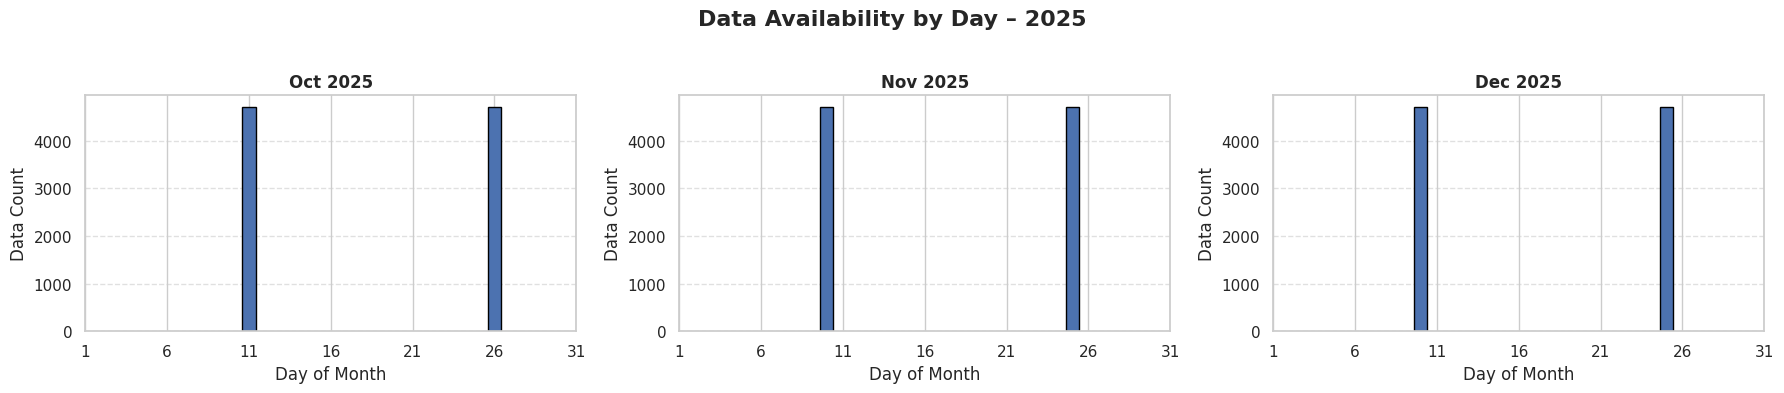

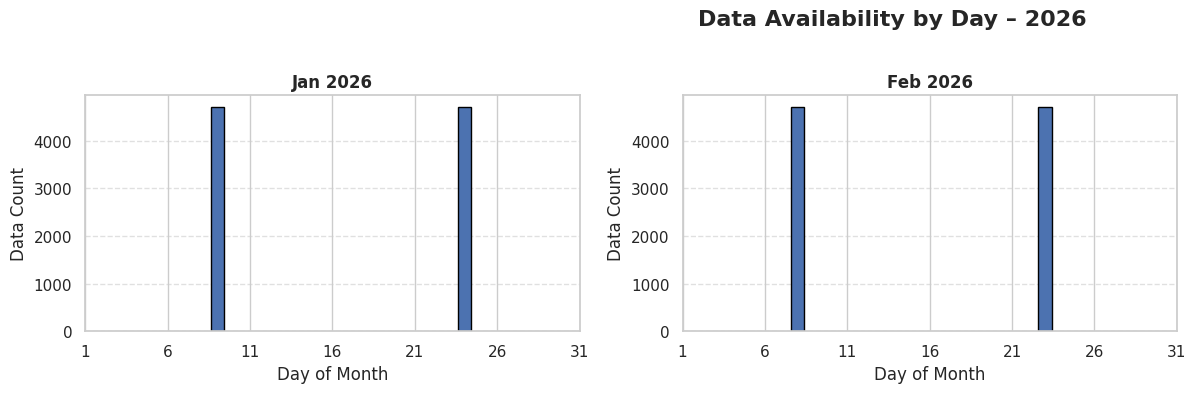

In [301]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

years = sorted(full_dataset['year'].dropna().unique())

for year in years:
    year_df = full_dataset[full_dataset['year'] == year]
    months = sorted(year_df['month'].dropna().unique())

    cols = 3
    rows = math.ceil(len(months) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten()

    for i, month in enumerate(months):
        ax = axes[i]
        month_df = year_df[year_df['month'] == month]
        day_counts = month_df['day'].value_counts().sort_index()

        ax.bar(day_counts.index, day_counts.values,
               edgecolor='black')
        ax.set_title(f'{month_labels[month-1]} {year}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Day of Month')
        ax.set_ylabel('Data Count')
        ax.set_xticks(range(1, 32, 5))
        ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f'Data Availability by Day – {year}', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # Save figure
    fig.savefig(f"plot_monthly_distribution_{year}_before_flagging.png",
                dpi=300, bbox_inches='tight')


In [302]:
full_dataset['date'].unique()

<DatetimeArray>
['2025-10-11 00:00:00', '2025-10-26 00:00:00', '2025-11-10 00:00:00',
 '2025-11-25 00:00:00', '2025-12-10 00:00:00', '2025-12-25 00:00:00',
 '2026-01-09 00:00:00', '2026-01-24 00:00:00', '2026-02-08 00:00:00',
 '2026-02-23 00:00:00']
Length: 10, dtype: datetime64[ns]

# Scatter plot of all the points

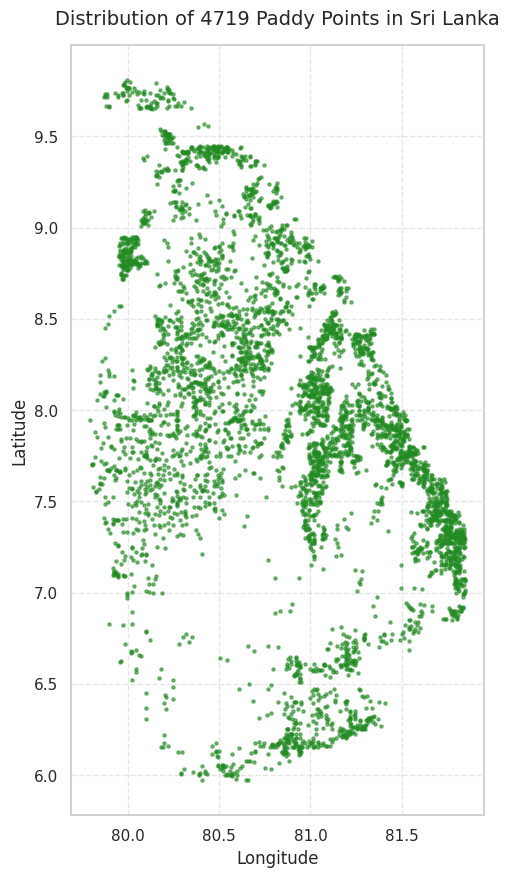

In [303]:
# 1. Extract only the unique geographical points
# We drop duplicates based on 'pixel_id' to get the ~4,719 unique locations
unique_points = full_dataset.drop_duplicates(subset=['pixel_id'])

# 2. Set up the plot dimensions (Taller than it is wide, like Sri Lanka)
plt.figure(figsize=(7, 10))

# 3. Create the scatter plot
# lon is X (horizontal), lat is Y (vertical)
plt.scatter(
    unique_points['lon'], 
    unique_points['lat'], 
    color='forestgreen',  # Green for paddy fields
    alpha=0.6,            # Slight transparency to see point density
    s=5                   # Small point size
)

# 4. Add labels and styling
plt.title('Distribution of 4719 Paddy Points in Sri Lanka', fontsize=14, pad=15)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Add a subtle grid to help read coordinates
plt.grid(True, linestyle='--', alpha=0.5)

# Ensure the aspect ratio is equal so the map isn't distorted
plt.gca().set_aspect('equal', adjustable='box')

# 5. Show the plot
plt.show()

In [304]:
len(unique_points)

4719

# Masking with nan

In [305]:
full_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47190 entries, 0 to 47189
Data columns (total 36 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   B1         47190 non-null  float32       
 1   B11        47190 non-null  float32       
 2   B12        47190 non-null  float32       
 3   B2         47190 non-null  float32       
 4   B3         47190 non-null  float32       
 5   B4         47190 non-null  float32       
 6   B5         47190 non-null  float32       
 7   B6         47190 non-null  float32       
 8   B7         47190 non-null  float32       
 9   B8         47190 non-null  float32       
 10  B8A        47190 non-null  float32       
 11  B9         47190 non-null  float32       
 12  SCL        47190 non-null  category      
 13  cloud_pct  47190 non-null  float64       
 14  date       47190 non-null  datetime64[ns]
 15  elevation  47190 non-null  float64       
 16  lat        47190 non-null  float64      

In [306]:
bands = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12']
full_dataset[bands] = full_dataset[bands].astype('float32') / 10000.0
    
# B. Define Strictly Clean Mask
# SCL 4=Veg, 5=Non-Veg, 6=Water, 7=Unclassified
clean_mask = (full_dataset['SCL'].astype(float).round().isin([4, 5, 6, 7])) & (full_dataset['cloud_pct'] <= 50)

# C. "Erase" bad data (Setting to NaN for the Imputation step)
full_dataset.loc[~clean_mask, bands] = np.nan
full_dataset['is_clean'] = clean_mask

In [307]:
full_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47190 entries, 0 to 47189
Data columns (total 37 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   B1         4799 non-null   float32       
 1   B11        4799 non-null   float32       
 2   B12        4799 non-null   float32       
 3   B2         4799 non-null   float32       
 4   B3         4799 non-null   float32       
 5   B4         4799 non-null   float32       
 6   B5         4799 non-null   float32       
 7   B6         4799 non-null   float32       
 8   B7         4799 non-null   float32       
 9   B8         4799 non-null   float32       
 10  B8A        4799 non-null   float32       
 11  B9         4799 non-null   float32       
 12  SCL        47190 non-null  category      
 13  cloud_pct  47190 non-null  float64       
 14  date       47190 non-null  datetime64[ns]
 15  elevation  47190 non-null  float64       
 16  lat        47190 non-null  float64      

# Filling nans

In [308]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

def prepare_dataset_for_bilstm(df):
    print("--- 🚀 Starting Spectral-Only Imputation Process ---")
    
    # 1. INITIAL CLEANUP: SCL Formatting
    if 'SCL' in df.columns:
        print("  > Formatting SCL category values for masking...")
        df['SCL'] = pd.to_numeric(df['SCL'], errors='coerce').round()
    
    # 2. DEFINE TARGET BANDS VS WEATHER
    # We explicitly define the spectral bands to be cleaned.
    spectral_bands = [
        'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12'
    ]
    # Filter only for bands that exist in your specific dataframe
    target_cols = [c for c in spectral_bands if c in df.columns]
    
    # Identify weather columns for verification print
    weather_keywords = ['rain', 'tmean', 'tmax', 'tmin', 'rh_mean', 't_day', 't_night']
    all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    weather_found = [c for c in all_numeric if any(k in c.lower() for k in weather_keywords)]
    
    print(f"  > Target bands to be imputed: {target_cols}")
    print(f"  > Weather columns to be preserved (untouched): {weather_found}")

    # 3. MASKING: Identify clean pixels
    valid_classes = [4, 5, 6, 7] # Vegetation, Soil, Water, Unclassified
    df["is_clean"] = (df["cloud_pct"] <= 50) & (df["SCL"].isin(valid_classes))
    
    clean_count = df["is_clean"].sum()
    print(f"  > Cloud-free data found: {clean_count} rows ({clean_count/len(df)*100:.2f}%)")

    # Initialize the filled dataframe
    df_filled = df.copy()
    
    # CRITICAL CHANGE: Only set target spectral bands to NaN in cloudy rows.
    # Weather columns (CHIRPS/ERA5) will keep their original values.
    print(f"  > Masking {len(target_cols)} spectral bands in cloudy rows...")
    df_filled.loc[~df_filled["is_clean"], target_cols] = np.nan
    
    # --- STEP 1: SPATIAL INTERPOLATION ---
    print(f"\n[Step 1/3] Spatial Interpolation (Nearest Neighbor) for {len(target_cols)} bands...")
    def spatial_fill(group):
        clean = group['is_clean']
        if clean.any() and (~clean).any():
            coords_c = group.loc[clean, ['lat', 'lon']].values
            vals_c = group.loc[clean, target_cols].values
            coords_d = group.loc[~clean, ['lat', 'lon']].values
            
            tree = cKDTree(coords_c)
            _, idx = tree.query(coords_d, k=1)
            group.loc[~clean, target_cols] = vals_c[idx]
        return group
    
    nan_before_spatial = df_filled[target_cols].isna().sum().sum()
    df_filled = df_filled.groupby('timestep', group_keys=False).apply(spatial_fill)
    nan_after_spatial = df_filled[target_cols].isna().sum().sum()
    print(f"  > Spatial fill fixed {nan_before_spatial - nan_after_spatial} band values.")

    # --- STEP 2: TEMPORAL INTERPOLATION ---
    print("[Step 2/3] Temporal Interpolation (Linear) for remaining gaps...")
    def temporal_fill(group):
        group = group.sort_values('timestep')
        subset = group[target_cols].copy()
        if subset.isna().any().any():
            subset = subset.interpolate(method='linear', limit_direction='both')
            group[target_cols] = subset
        return group
    
    df_filled = df_filled.groupby('pixel_id', group_keys=False).apply(temporal_fill)
    final_nan_count = df_filled[target_cols].isna().sum().sum()
    print(f"  > Temporal fill complete. Remaining NaNs in bands: {final_nan_count}")

    # --- STEP 3: FALLBACK & FINAL ROUNDING ---
    print("\n[Step 3/3] Finalizing Data & SCL Cleanup...")
    
    # Fallback only for spectral bands that were cloudy for the entire year
    if final_nan_count > 0:
        print(f"  > Applying global mean fallback for {final_nan_count} persistent band gaps.")
        column_means = df.loc[df["is_clean"], target_cols].mean().fillna(0)
        df_filled[target_cols] = df_filled[target_cols].fillna(column_means)

    if 'SCL' in df_filled.columns:
        df_filled['SCL'] = df_filled['SCL'].round().clip(4, 7).astype(int)

    # Verification: Ensure weather columns didn't gain any NaNs from our masking
    weather_nans = df_filled[weather_found].isna().sum().sum()
    print(f"  > Verification: Weather columns have {weather_nans} NaNs (should be 0 or unchanged).")

    print("--- ✅ Process Complete: Spectral bands filled, Weather preserved ---")
    return df_filled

df = prepare_dataset_for_bilstm(full_dataset)
df.info()

--- 🚀 Starting Spectral-Only Imputation Process ---
  > Formatting SCL category values for masking...
  > Target bands to be imputed: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12']
  > Weather columns to be preserved (untouched): ['rain_14d', 'rain_1d', 'rain_30d', 'rain_3d', 'rain_7d', 'rh_mean', 't_day', 't_night', 'tmax', 'tmean', 'tmin']
  > Cloud-free data found: 4799 rows (10.17%)
  > Masking 12 spectral bands in cloudy rows...

[Step 1/3] Spatial Interpolation (Nearest Neighbor) for 12 bands...
  > Spatial fill fixed 55668 band values.
[Step 2/3] Temporal Interpolation (Linear) for remaining gaps...


/tmp/ipykernel_55/408145159.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filled = df_filled.groupby('timestep', group_keys=False).apply(spatial_fill)


  > Temporal fill complete. Remaining NaNs in bands: 0

[Step 3/3] Finalizing Data & SCL Cleanup...
  > Verification: Weather columns have 0 NaNs (should be 0 or unchanged).
--- ✅ Process Complete: Spectral bands filled, Weather preserved ---
<class 'pandas.core.frame.DataFrame'>
Index: 47190 entries, 9 to 47180
Data columns (total 37 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   B1         47190 non-null  float32       
 1   B11        47190 non-null  float32       
 2   B12        47190 non-null  float32       
 3   B2         47190 non-null  float32       
 4   B3         47190 non-null  float32       
 5   B4         47190 non-null  float32       
 6   B5         47190 non-null  float32       
 7   B6         47190 non-null  float32       
 8   B7         47190 non-null  float32       
 9   B8         47190 non-null  float32       
 10  B8A        47190 non-null  float32       
 11  B9         47190 non-null  float32   

/tmp/ipykernel_55/408145159.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filled = df_filled.groupby('pixel_id', group_keys=False).apply(temporal_fill)


In [309]:
df.head()

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,...,t_night,timestep,tmax,tmean,tmin,year,month,day,month_day,is_clean
9,0.42785,0.299950,0.26830,0.452750,0.443650,0.433500,0.48935,0.500600,0.507800,0.495000,...,24.576300,1,30.268335,26.015411,22.480951,2026,2,23,02-23,False
8,0.42785,0.299950,0.26830,0.452750,0.443650,0.433500,0.48935,0.500600,0.507800,0.495000,...,24.906046,2,30.195658,25.973188,21.905070,2026,2,8,02-08,False
7,0.42785,0.299950,0.26830,0.452750,0.443650,0.433500,0.48935,0.500600,0.507800,0.495000,...,23.831856,3,29.617517,24.962242,21.198465,2026,1,24,01-24,True
6,0.40985,0.310314,0.26645,0.413757,0.409471,0.401079,0.45875,0.481664,0.492714,0.479671,...,24.595488,4,29.219248,25.459166,22.709513,2026,1,9,01-09,False
5,0.39185,0.320679,0.26460,0.374764,0.375293,0.368657,0.42815,0.462729,0.477629,0.464343,...,24.728739,5,28.700220,25.402454,22.851633,2025,12,25,12-25,False


In [310]:
df['is_clean']

9        False
8        False
7         True
6        False
5        False
         ...  
47184    False
47183    False
47182    False
47181    False
47180     True
Name: is_clean, Length: 47190, dtype: bool

In [311]:
df['SCL'].unique

<bound method Series.unique of 9        7
8        5
7        7
6        7
5        7
        ..
47184    6
47183    7
47182    7
47181    5
47180    6
Name: SCL, Length: 47190, dtype: int64>

<Axes: >

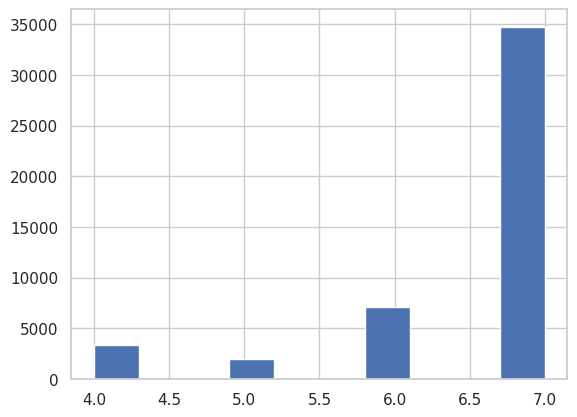

In [312]:
df['SCL'].hist()

In [313]:
def engineer_features(df, eps=1e-6, scale_factor=10000.0):
    """
    Compute vegetation and spectral indices from Sentinel-2 bands safely.
    Automatically scales reflectance, prevents division errors, and clips
    indices to physically meaningful ranges.
    """
    # ---------------------------------------------------------------
    # 2️⃣ Compute all derived indices with safe division and clipping
    # ---------------------------------------------------------------
    df['NDVI']  = np.clip((df['B8'] - df['B4']) / (df['B8'] + df['B4'] + eps), -1, 1)
    df['GLI']   = np.clip((2*df['B3'] - df['B4'] - df['B2']) / (2*df['B3'] + df['B4'] + df['B2'] + eps), -1, 1)
    df['CVI']   = np.clip((df['B8'] * df['B4']) / (df['B3']**2 + eps), 0, 30)
    df['SIPI']  = np.clip((df['B8'] - df['B2']) / (df['B8'] - df['B4'] + eps), 0, 2)
    df['S2REP'] = np.clip(705 + 35 * (((df['B7'] + df['B4'])/2 - df['B5']) / (df['B6'] - df['B5'] + eps)), 680, 750)
    df['CCCI']  = np.clip(((df['B8'] - df['B5'])*(df['B8'] + df['B4'])) / (((df['B8'] + df['B5'])*(df['B8'] - df['B4'])) + eps), 0, 2)
    df['RENDVI']= np.clip((df['B6'] - df['B5']) / (df['B6'] + df['B5'] + eps), -1, 1)
    df['RECI']  = np.clip((df['B8'] / (df['B5'] + eps)) - 1.0, 0, 10)
    df['EVI']   = np.clip((2.5 * (df['B8'] - df['B4'])) / (df['B8'] + 6*df['B4'] - 7.5*df['B2'] + 1 + eps), -1, 1)
    df['EVI2']  = np.clip(2.4 * (df['B8'] - df['B4']) / (df['B8'] + df['B4'] + 1 + eps), -1, 1)
    df['NDWI']  = np.clip((df['B4'] - df['B2']) / (df['B4'] + df['B2'] + eps), -1, 1)
    df['NPCRI'] = np.clip((df['B3'] - df['B8']) / (df['B3'] + df['B8'] + eps), -1, 1)
    df['LSWI']  = np.clip((df['B8'] - df['B11']) / (df['B8'] + df['B11'] + eps), -1, 1)
    df['GCI']   = np.clip((df['B8'] / (df['B3'] + eps)) - 1.0, 0, 10)
    
    df['BSI']   = np.clip((df['B11'] + df['B4'] - df['B8'] - df['B2']) / (df['B11'] + df['B4'] + df['B8'] + df['B2'] + eps), -1, 1)
    df['NDSMI'] = np.clip((df['B8'] - df['B11']) / (df['B8'] + df['B11'] + eps), -1, 1)

    return df
df = engineer_features(df, eps=1e-6, scale_factor=10000.0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47190 entries, 9 to 47180
Data columns (total 53 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   B1         47190 non-null  float32       
 1   B11        47190 non-null  float32       
 2   B12        47190 non-null  float32       
 3   B2         47190 non-null  float32       
 4   B3         47190 non-null  float32       
 5   B4         47190 non-null  float32       
 6   B5         47190 non-null  float32       
 7   B6         47190 non-null  float32       
 8   B7         47190 non-null  float32       
 9   B8         47190 non-null  float32       
 10  B8A        47190 non-null  float32       
 11  B9         47190 non-null  float32       
 12  SCL        47190 non-null  int64         
 13  cloud_pct  47190 non-null  float64       
 14  date       47190 non-null  datetime64[ns]
 15  elevation  47190 non-null  float64       
 16  lat        47190 non-null  float64       
 17

In [314]:
import pandas as pd
import numpy as np

def process_pipeline_for_inference(df):
    print("📦 Starting 10-day Aggregation (Full Column Retention)...")
    
    # Ensure date is datetime
    df['date'] = pd.to_datetime(df['date'])
    df['ten_day'] = df['date'].dt.to_period('10D')
    
    # 1. Define Groups
    spectral_indices = [
        'NDVI','EVI','EVI2','LSWI','NDWI','GLI','GCI','CVI',
        'SIPI','RENDVI','RECI','CCCI','S2REP','BSI','NPCRI','NDSMI'
    ]
    
    raw_bands = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12']
    
    env_cols = [
        'rain_1d','rain_3d','rain_7d','rain_14d','rain_30d',
        'tmean','tmax','tmin','t_day','t_night','rh_mean'
    ]
    
    # Metadata/Static (Things that shouldn't change much or are IDs)
    static_meta = [
        'lat','lon','elevation','slope','pixel_id','year',
        'month','day','month_day','is_clean','timestep','SCL','cloud_pct', 'date','year','month','month_day'
    ]

    # 2. Build the "Keep Everything" Dictionary
    agg_dict = {}
    
    # Median for indices and raw bands (Robust against outliers)
    for col in (spectral_indices + raw_bands):
        if col in df.columns:
            agg_dict[col] = 'median'
            
    # Mean for weather
    for col in env_cols:
        if col in df.columns:
            agg_dict[col] = 'mean'
            
    # First/Max for metadata and IDs
    for col in static_meta:
        if col in df.columns:
            # For bools or classes, 'max' or 'first' works best
            agg_dict[col] = 'first' 

    # 3. Perform Aggregation
    # This now uses the dictionary containing all your columns
    df_agg = df.groupby(['pixel_id', 'ten_day'], as_index=False).agg(agg_dict)
    
    # Reconstruct timeline
    df_agg['ten_day_start'] = df_agg['ten_day'].dt.start_time
    df_agg = df_agg.sort_values(['pixel_id', 'ten_day_start'])

    # 4. TIME FEATURES
    print("🔄 Calculating time features...")
    df_agg["delta_days"] = df_agg.groupby("pixel_id")["ten_day_start"].diff().dt.days.fillna(10)
    df_agg['doy'] = df_agg['ten_day_start'].dt.dayofyear
    df_agg['doy_sin'] = np.sin(2 * np.pi * df_agg['doy'] / 365.25)
    df_agg['doy_cos'] = np.cos(2 * np.pi * df_agg['doy'] / 365.25)

    # 5. RENAME (Suffixes)
    # Only renaming the ones explicitly mentioned in your training suffixes
    rename_map = {col: f"{col}_median" for col in spectral_indices if col in df_agg.columns}
    rename_map.update({col: f"{col}_mean" for col in env_cols if col in df_agg.columns})
    
    df_agg = df_agg.rename(columns=rename_map)

    # 6. CLEANUP
    df_agg = df_agg.drop(columns=['ten_day'])
    
    print(f"✅ Aggregation complete. Retained {len(df_agg.columns)} columns.")
    return df_agg

# Execute
df = process_pipeline_for_inference(df)

📦 Starting 10-day Aggregation (Full Column Retention)...
🔄 Calculating time features...
✅ Aggregation complete. Retained 58 columns.


In [315]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47190 entries, 0 to 47189
Data columns (total 58 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   NDVI_median    47190 non-null  float32       
 1   EVI_median     47190 non-null  float32       
 2   EVI2_median    47190 non-null  float32       
 3   LSWI_median    47190 non-null  float32       
 4   NDWI_median    47190 non-null  float32       
 5   GLI_median     47190 non-null  float32       
 6   GCI_median     47190 non-null  float32       
 7   CVI_median     47190 non-null  float32       
 8   SIPI_median    47190 non-null  float32       
 9   RENDVI_median  47190 non-null  float32       
 10  RECI_median    47190 non-null  float32       
 11  CCCI_median    47190 non-null  float32       
 12  S2REP_median   47190 non-null  float32       
 13  BSI_median     47190 non-null  float32       
 14  NPCRI_median   47190 non-null  float32       
 15  NDSMI_median   4719

In [316]:
df.head()

,NDVI_median,EVI_median,EVI2_median,LSWI_median,NDWI_median,GLI_median,GCI_median,CVI_median,SIPI_median,RENDVI_median,...,is_clean,timestep,SCL,cloud_pct,date,ten_day_start,delta_days,doy,doy_sin,doy_cos
0,0.304838,0.354223,0.272705,0.019995,0.069238,0.028234,0.896762,1.916677,1.147661,0.144434,...,False,10,7,49.869860,2025-10-11,2025-10-11,10.0,284,-0.985056,0.172236
1,0.255540,0.342954,0.239791,0.053443,0.044081,0.020743,0.689284,1.692043,1.122990,0.117268,...,False,9,6,76.847166,2025-10-26,2025-10-26,15.0,299,-0.908492,0.417903
2,0.213069,0.330013,0.208737,0.086460,0.025714,0.015200,0.533803,1.526116,1.092581,0.093728,...,False,8,7,63.695670,2025-11-10,2025-11-10,15.0,314,-0.771773,0.635898
3,0.176097,0.314998,0.179391,0.119055,0.011715,0.010934,0.412948,1.398569,1.054166,0.073133,...,False,7,7,78.155253,2025-11-25,2025-11-25,15.0,329,-0.583951,0.811789
4,0.143621,0.297367,0.151614,0.151234,0.000691,0.007548,0.316312,1.297479,1.004108,0.054963,...,False,6,4,57.174064,2025-12-10,2025-12-10,15.0,344,-0.357464,0.933927


In [317]:
df[['ten_day_start','date']]

,ten_day_start,date
0,2025-10-11,2025-10-11
1,2025-10-26,2025-10-26
2,2025-11-10,2025-11-10
3,2025-11-25,2025-11-25
4,2025-12-10,2025-12-10
...,...,...
47185,2025-12-25,2025-12-25
47186,2026-01-09,2026-01-09
47187,2026-01-24,2026-01-24
47188,2026-02-08,2026-02-08


📈 Generating plots for 2025...


/tmp/ipykernel_55/3780906281.py:54: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


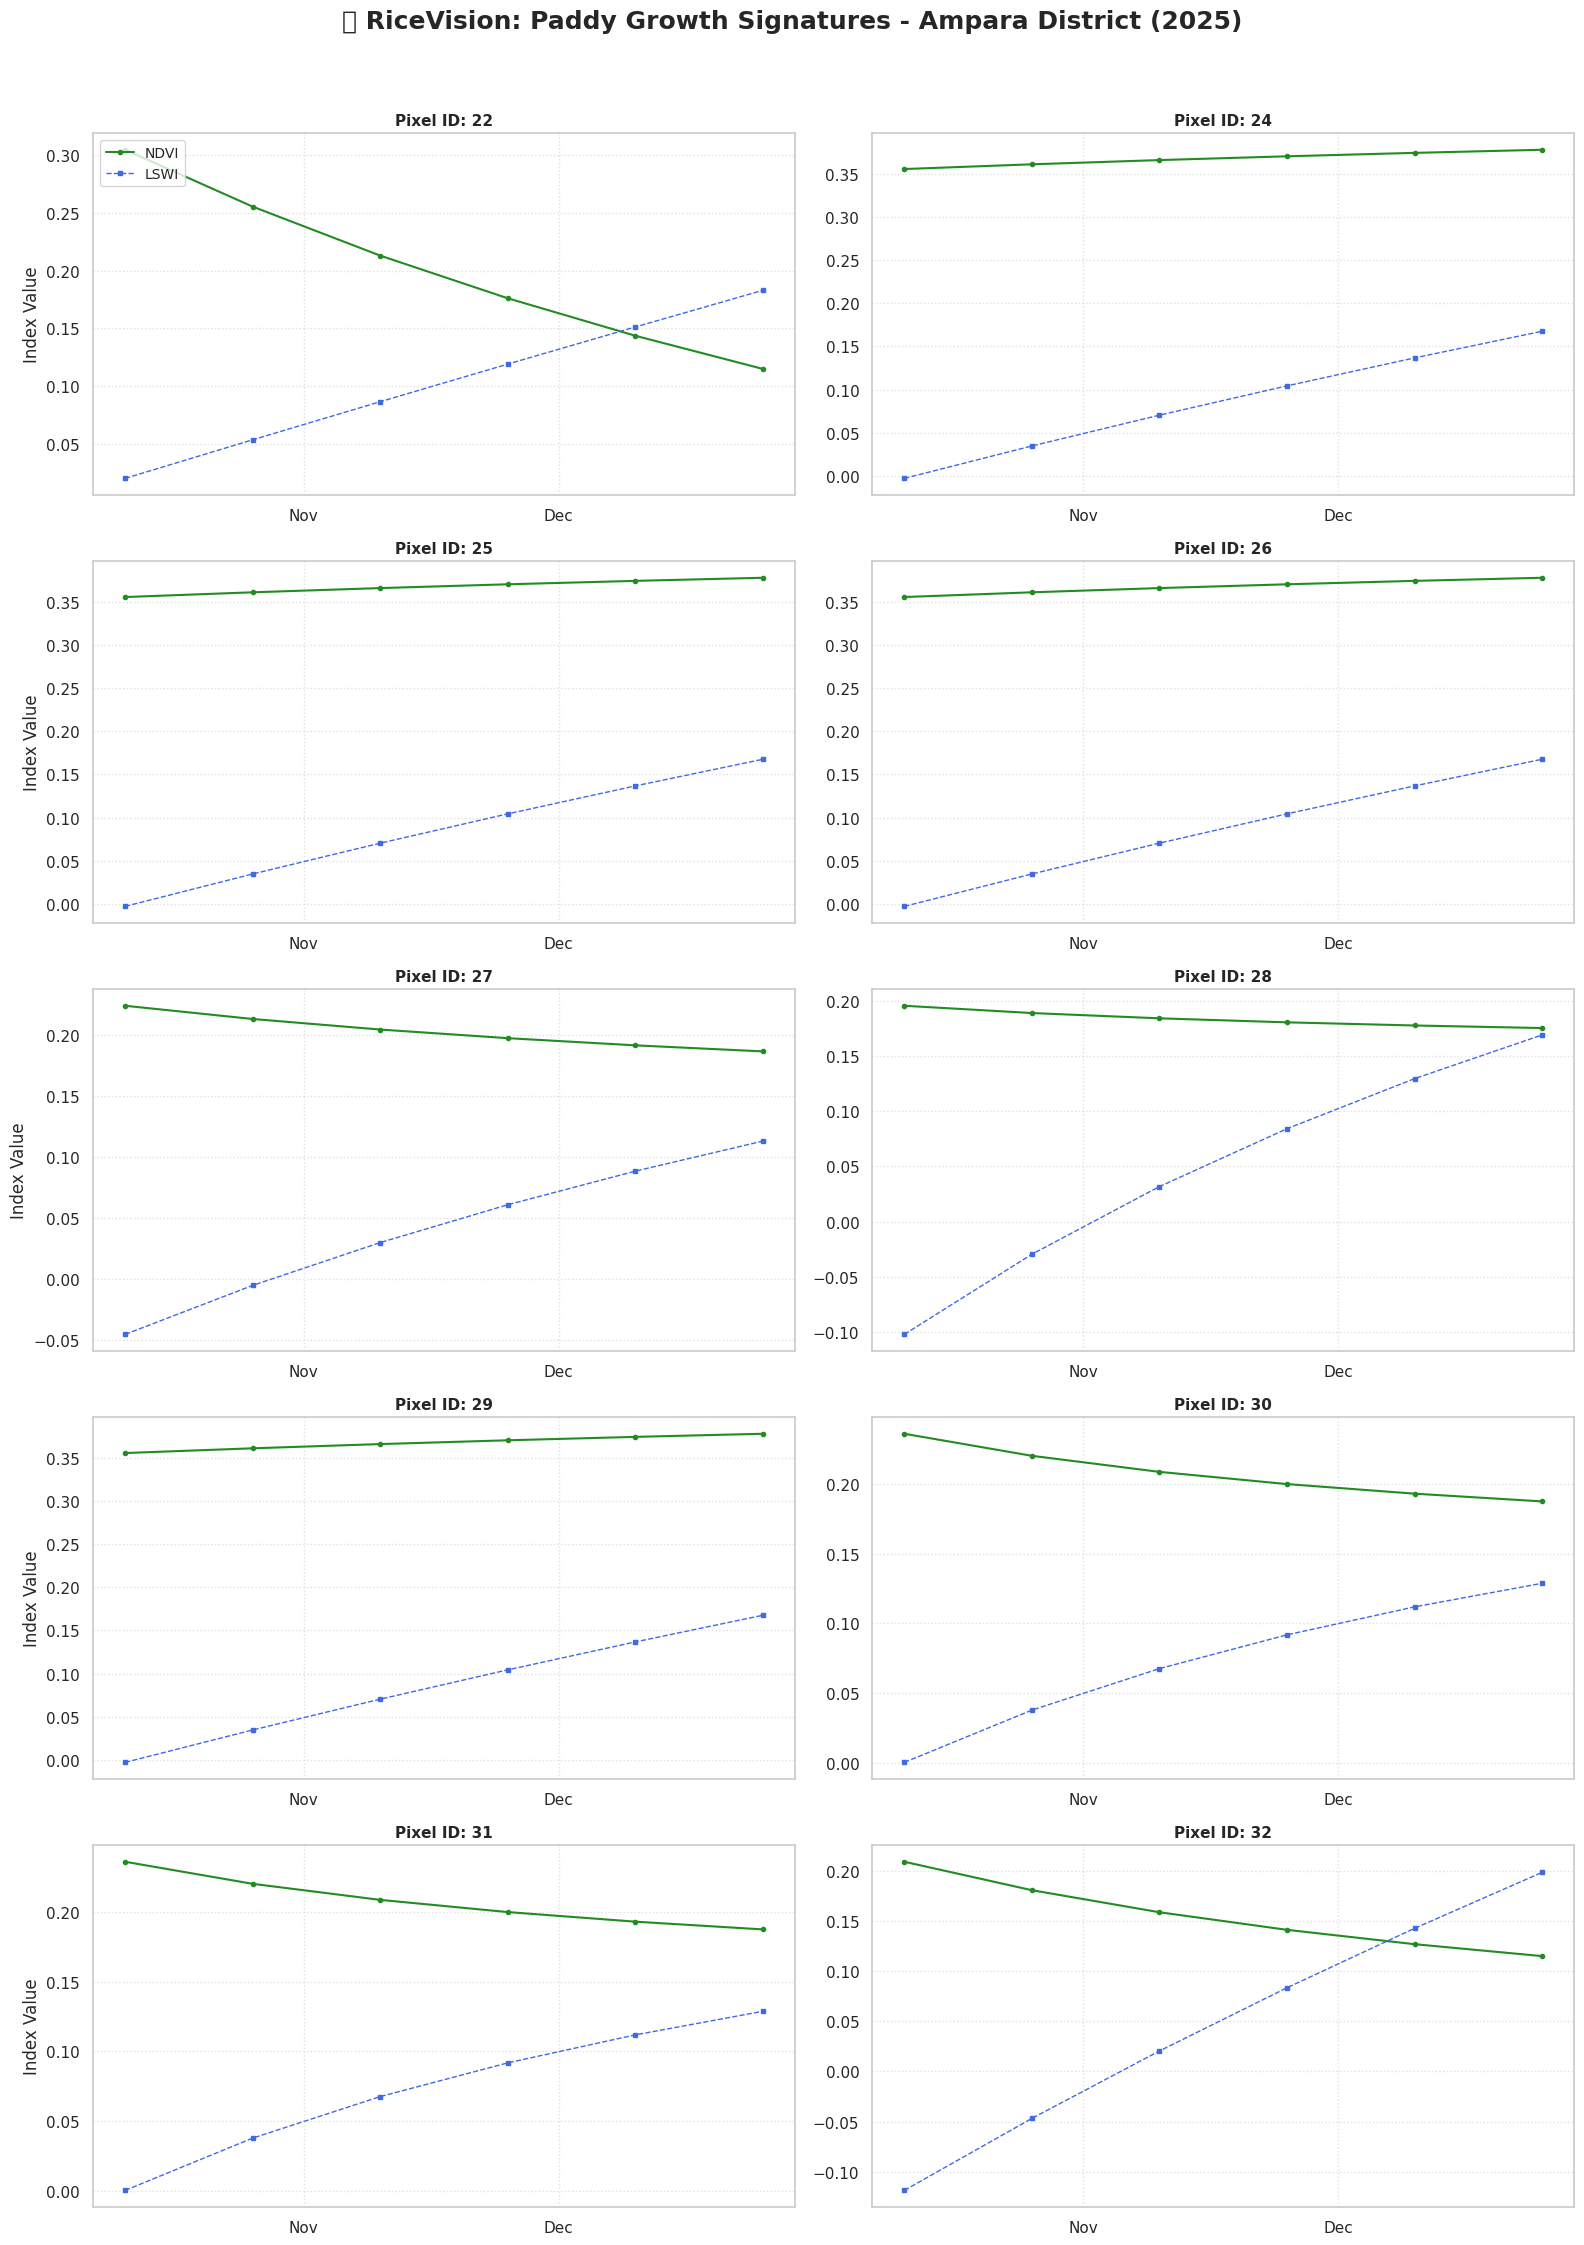

📈 Generating plots for 2026...


/tmp/ipykernel_55/3780906281.py:54: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


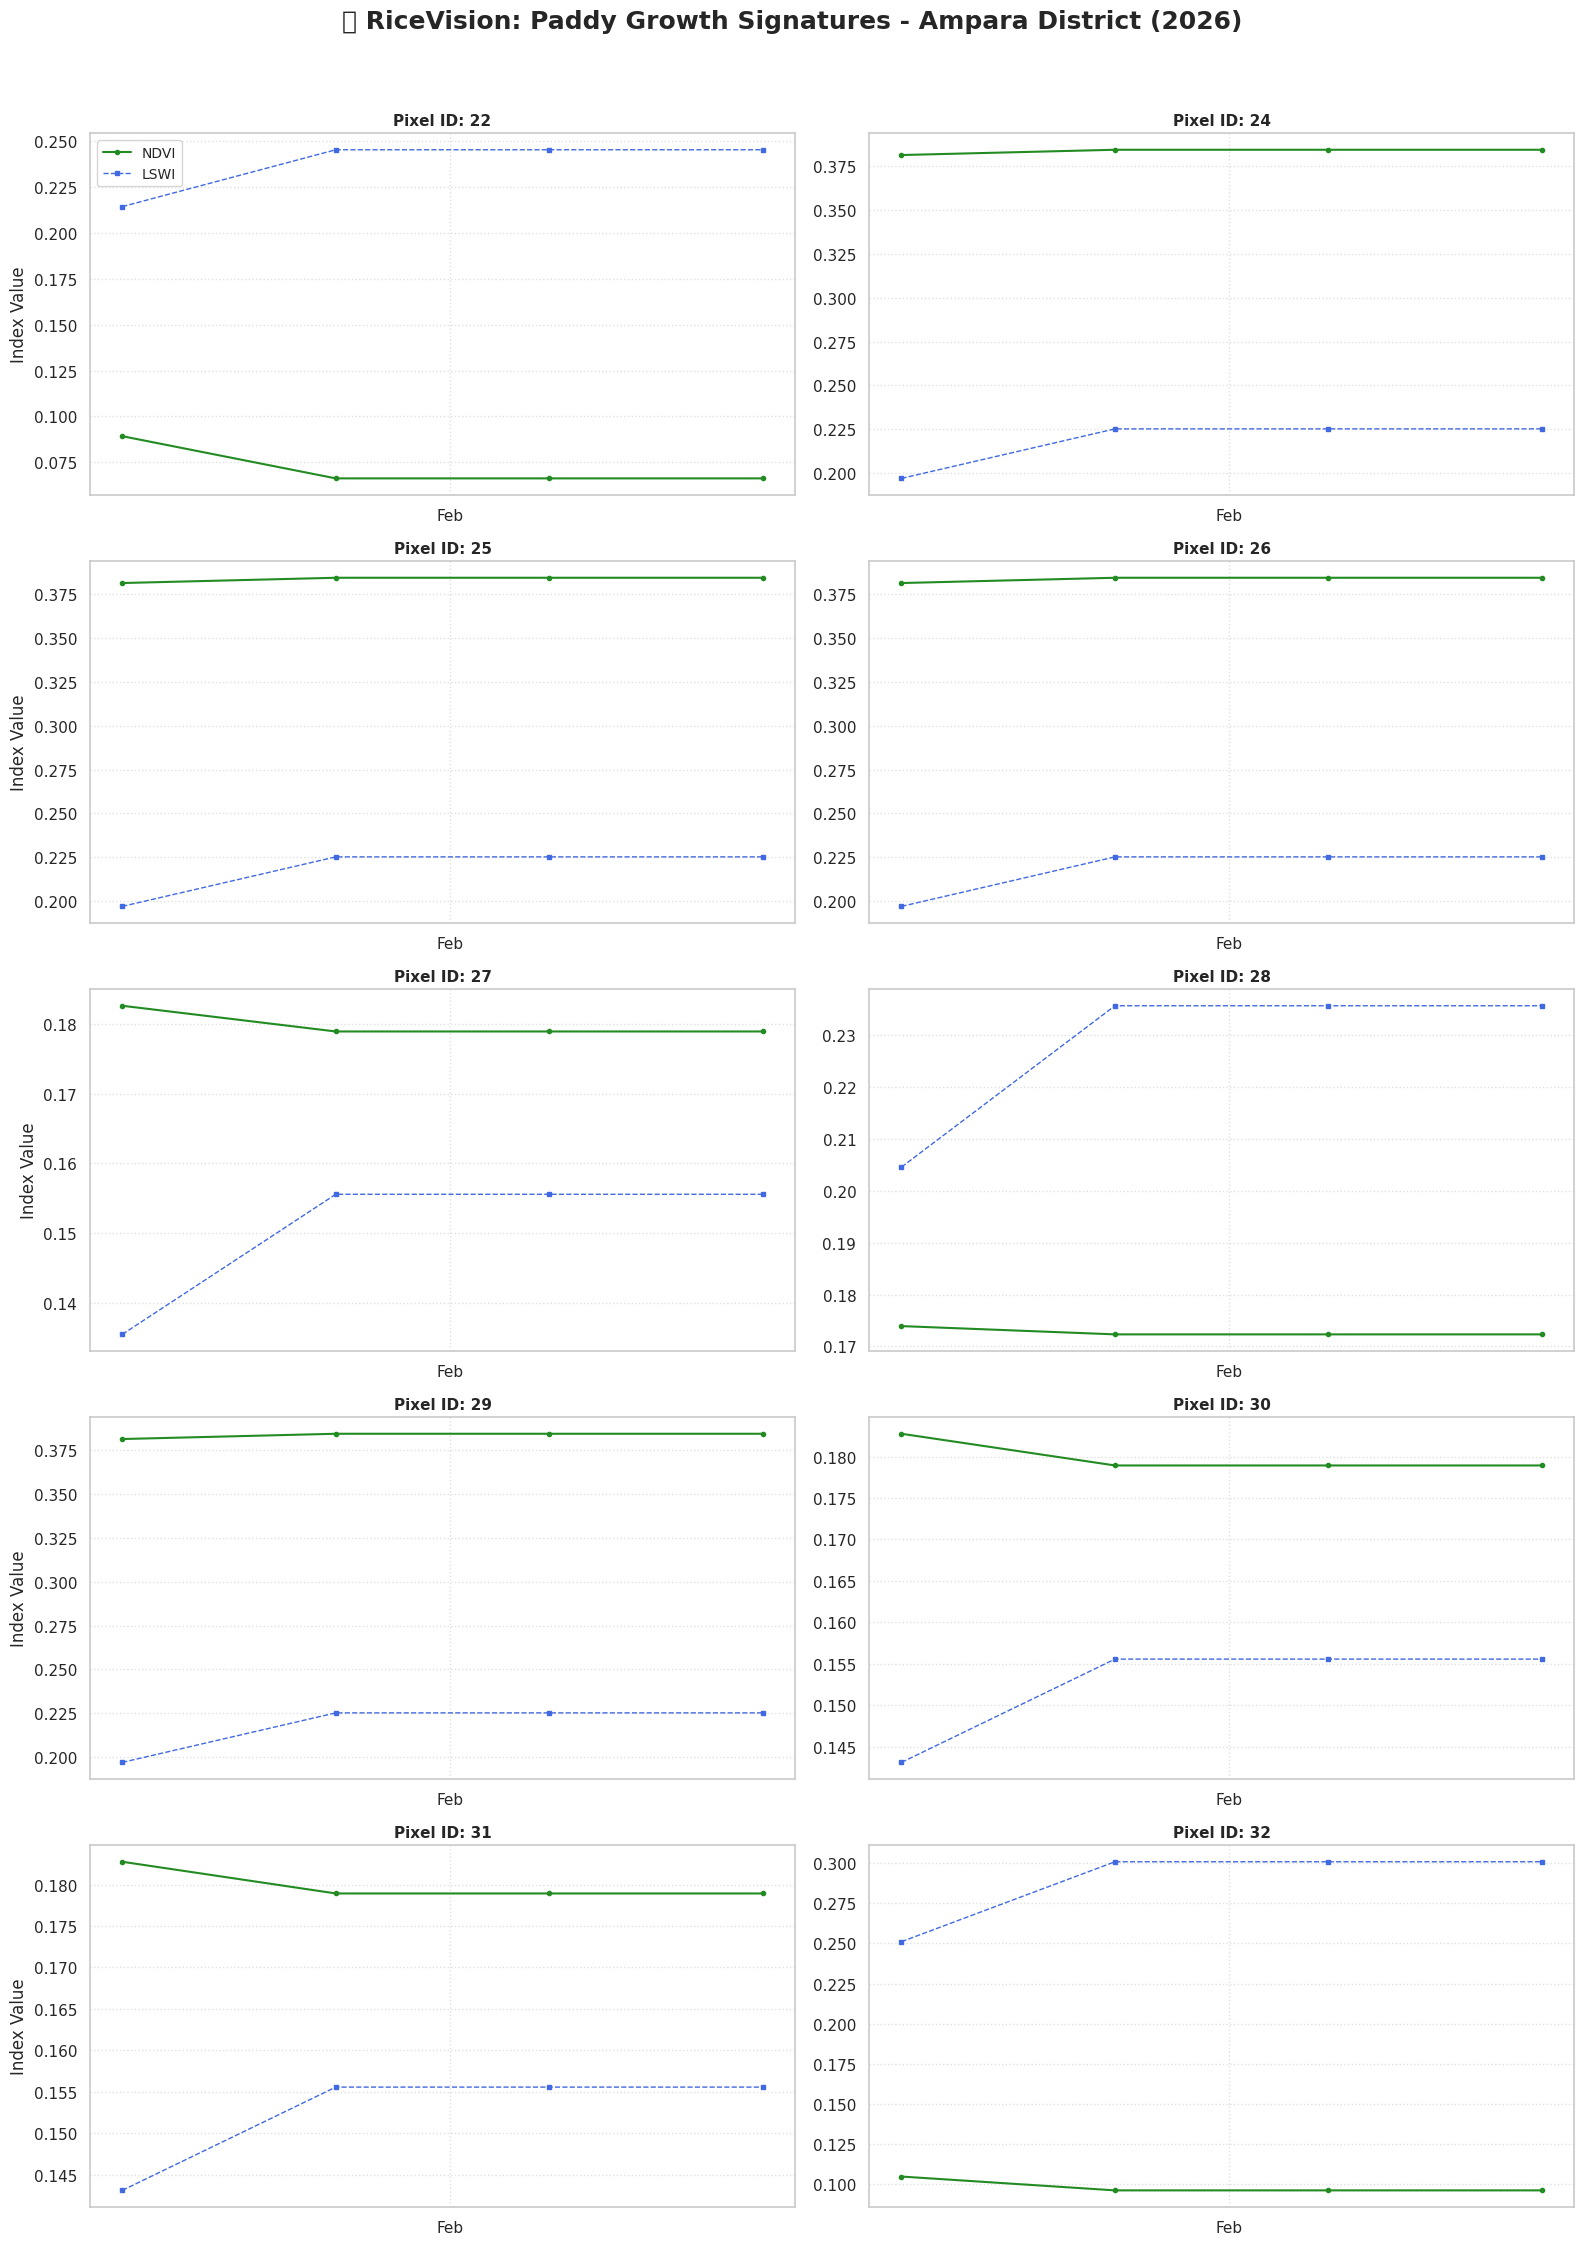

In [318]:
# --- Configuration ---
years_to_plot = [2025, 2026]
pixels_per_year = 10

for year in years_to_plot:
    # 1. Filter data for the specific year
    df_year = df[df['year'] == year].copy()
    
    if df_year.empty:
        print(f"⚠️ No data found for year {year}. Skipping...")
        continue
    
    # 2. Select 10 unique pixel IDs to visualize
    unique_pixels = df_year['pixel_id'].unique()[:pixels_per_year]
    
    # 3. Initialize a 5x2 grid for this year
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 22))
    axes = axes.flatten()  # Flatten for easy iteration
    
    print(f"📈 Generating plots for {year}...")

    for i, pixel_id in enumerate(unique_pixels):
        ax = axes[i]
        
        # Filter and prepare data for the specific pixel
        df_pixel = df_year[df_year['pixel_id'] == pixel_id].copy()
        
        # Convert Period to Timestamp and Sort
        df_pixel['plot_date'] = df_pixel['ten_day_start']
        df_pixel = df_pixel.sort_values('plot_date')
        
        # Plot NDVI and LSWI
        ax.plot(df_pixel['plot_date'], df_pixel['NDVI_median'], 
                label='NDVI', color='forestgreen', marker='o', markersize=3, linewidth=1.5)
        ax.plot(df_pixel['plot_date'], df_pixel['LSWI_median'], 
                label='LSWI', color='royalblue', marker='s', markersize=3, linestyle='--', linewidth=1)
        
        # --- CLEAN X-AXIS ---
        # Show month names only (e.g., Jan, Feb) to save space
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        
        # Styling
        ax.set_title(f"Pixel ID: {pixel_id}", fontsize=11, fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)
        if i % 2 == 0: ax.set_ylabel("Index Value")
        
        # Only show legend on the first plot to reduce clutter
        if i == 0:
            ax.legend(loc='upper left', fontsize='small', frameon=True)

    plt.suptitle(f"🌾 RiceVision: Paddy Growth Signatures - Ampara District ({year})", 
                 fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_55/688272659.py:35: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


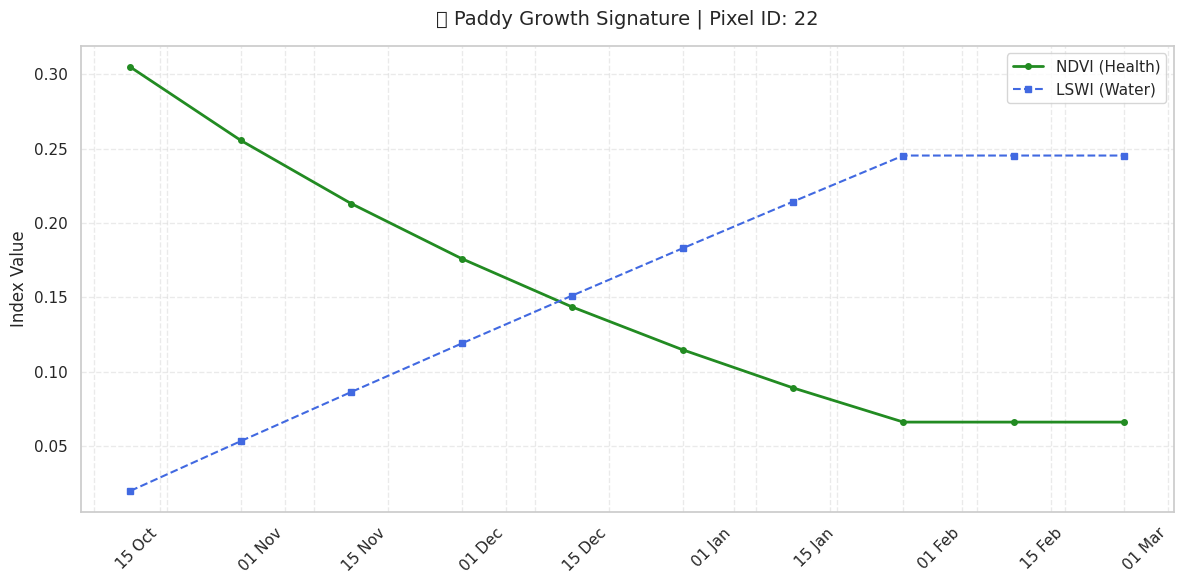

In [319]:
# 1. Filter for your specific pixel
target_pixel = df['pixel_id'].iloc[2]
df_pixel = df[df['pixel_id'] == target_pixel].copy()

# 2. Convert Period to Timestamp for better plotting logic
# This allows Matplotlib to treat the X-axis as a timeline, not just a list of names
df_pixel['plot_date'] = df_pixel['ten_day_start']
df_pixel = df_pixel.sort_values('plot_date')

# 3. Plotting
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_pixel['plot_date'], df_pixel['NDVI_median'], label='NDVI (Health)', 
        marker='o', color='forestgreen', linewidth=2, markersize=4)

ax.plot(df_pixel['plot_date'], df_pixel['LSWI_median'], label='LSWI (Water)', 
        marker='s', color='royalblue', linestyle='--', linewidth=1.5, markersize=4)

# --- CLEAN X-AXIS LOGIC ---
# Format the date to show Day and Month (e.g., "01 Jan")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# Automatically find the best interval so labels don't overlap
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

# Optional: Add a minor locator for every 10 days to show the composite steps
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=10))

plt.xticks(rotation=45, ha='right') # Slant them for better fitting
plt.title(f"🌾 Paddy Growth Signature | Pixel ID: {target_pixel}", fontsize=14, pad=15)
plt.ylabel("Index Value")
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend(frameon=True, loc='best')

plt.tight_layout()
plt.show()

# Pixels to districts

In [320]:
import pandas as pd
import numpy as np

# 1. Official Center Points for Sri Lankan Districts (Exact matches to your CSV names)
DISTRICT_CENTERS = {
    'Ampara': (7.28, 81.67), 'Anuradhapura': (8.31, 80.41), 'Badulla': (6.99, 81.05),
    'Batticaloa': (7.71, 81.70), 'Colombo': (6.92, 79.86), 'Galle': (6.05, 80.22),
    'Gampaha': (7.08, 80.00), 'Hambantota': (6.14, 81.12), 'Jaffna': (9.66, 80.01),
    'Kaluthara': (6.58, 79.96), 'Kandy': (7.29, 80.63), 'Kegalle': (7.25, 80.34),
    'Kilinochchi': (9.38, 80.40), 'Kurunegala': (7.48, 80.36), 'Mannar': (8.98, 79.91),
    'Matale': (7.46, 80.62), 'Matara': (5.94, 80.53), 'Monaragala': (6.87, 81.35),
    'Mullaitivu': (9.27, 80.81), 'Nuwara Eliya': (6.97, 80.78), 'Polonnaruwa': (7.94, 81.00),
    'Puttalam': (8.03, 79.82), 'Ratnapura': (6.68, 80.40), 'Trincomalee': (8.57, 81.23),
    'Vavuniya': (8.75, 80.50)
}

def map_pixels_to_districts(df):
    """
    Finds the nearest district for every pixel in the dataframe.
    Calculates mapping only once per unique pixel_id for speed.
    """
    print("📍 Mapping pixel coordinates to Districts...")
    
    # Extract unique pixels to save computation time
    pixel_coords = df[['pixel_id', 'lat', 'lon']].drop_duplicates()
    
    def find_closest(row):
        lat, lon = row['lat'], row['lon']
        # Calculate Euclidean distance to all centers
        distances = {
            district: np.sqrt((lat - center[0])**2 + (lon - center[1])**2)
            for district, center in DISTRICT_CENTERS.items()
        }
        # Return district with smallest distance
        return min(distances, key=distances.get)

    pixel_coords['district'] = pixel_coords.apply(find_closest, axis=1)
    
    # Merge the district column back into the main dataframe
    df = df.merge(pixel_coords[['pixel_id', 'district']], on='pixel_id', how='left')
    
    print(f"✅ Mapping complete. Unique districts found: {df['district'].unique()}")
    return df

# Execute
df = map_pixels_to_districts(df)

📍 Mapping pixel coordinates to Districts...
✅ Mapping complete. Unique districts found: ['Puttalam' 'Gampaha' 'Jaffna' 'Mannar' 'Colombo' 'Kurunegala' 'Kaluthara'
 'Kegalle' 'Galle' 'Anuradhapura' 'Kilinochchi' 'Vavuniya' 'Ratnapura'
 'Matara' 'Matale' 'Mullaitivu' 'Polonnaruwa' 'Kandy' 'Hambantota'
 'Nuwara Eliya' 'Trincomalee' 'Badulla' 'Monaragala' 'Ampara' 'Batticaloa']


In [321]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47190 entries, 0 to 47189
Data columns (total 59 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   NDVI_median    47190 non-null  float32       
 1   EVI_median     47190 non-null  float32       
 2   EVI2_median    47190 non-null  float32       
 3   LSWI_median    47190 non-null  float32       
 4   NDWI_median    47190 non-null  float32       
 5   GLI_median     47190 non-null  float32       
 6   GCI_median     47190 non-null  float32       
 7   CVI_median     47190 non-null  float32       
 8   SIPI_median    47190 non-null  float32       
 9   RENDVI_median  47190 non-null  float32       
 10  RECI_median    47190 non-null  float32       
 11  CCCI_median    47190 non-null  float32       
 12  S2REP_median   47190 non-null  float32       
 13  BSI_median     47190 non-null  float32       
 14  NPCRI_median   47190 non-null  float32       
 15  NDSMI_median   4719

In [322]:
df['district'].unique()

array(['Puttalam', 'Gampaha', 'Jaffna', 'Mannar', 'Colombo', 'Kurunegala',
       'Kaluthara', 'Kegalle', 'Galle', 'Anuradhapura', 'Kilinochchi',
       'Vavuniya', 'Ratnapura', 'Matara', 'Matale', 'Mullaitivu',
       'Polonnaruwa', 'Kandy', 'Hambantota', 'Nuwara Eliya',
       'Trincomalee', 'Badulla', 'Monaragala', 'Ampara', 'Batticaloa'],
      dtype=object)

# Smoothing

In [323]:
# 1. Configuration
# Note: Ensure WINDOW_LENGTH is odd and larger than POLY_ORDER
WINDOW_LENGTH = 5  
POLY_ORDER = 2
# Extract all column names that end with '_median'
target_cols = [col for col in df.columns if col.endswith('_median')]

# Print the list to verify
print("✅ Extracted Target Columns:")
print(target_cols)

# 2. Sort the data to ensure temporal consistency per pixel
# This is crucial so the filter processes time steps in the correct order
df = df.sort_values(by=['pixel_id', 'ten_day_start'])

# 3. Define the smoothing function
def smooth_pixel_wise(group):
    # Only apply filter if the pixel has enough data points to satisfy the window length
    if len(group) >= WINDOW_LENGTH:
        for col in target_cols:
            if col in group.columns:
                # Direct application of Savgol filter (no interpolation needed)
                group[f"{col}_smooth"] = savgol_filter(group[col], WINDOW_LENGTH, POLY_ORDER)
    else:
        # For short sequences, keep raw values to avoid errors
        for col in target_cols:
            if col in group.columns:
                group[f"{col}_smooth"] = group[col]
    return group

# 4. Apply the smoothing per pixel_id
print("⏳ Smoothing 10-day indices per pixel...")
df = df.groupby('pixel_id', group_keys=False).apply(smooth_pixel_wise)

print("✅ Pixel-wise smoothing complete.")
# Preview the new columns
print(df[[col + '_smooth' for col in target_cols]].head())

✅ Extracted Target Columns:
['NDVI_median', 'EVI_median', 'EVI2_median', 'LSWI_median', 'NDWI_median', 'GLI_median', 'GCI_median', 'CVI_median', 'SIPI_median', 'RENDVI_median', 'RECI_median', 'CCCI_median', 'S2REP_median', 'BSI_median', 'NPCRI_median', 'NDSMI_median']
⏳ Smoothing 10-day indices per pixel...
✅ Pixel-wise smoothing complete.
   NDVI_median_smooth  EVI_median_smooth  EVI2_median_smooth  \
0            0.304600           0.354131            0.272676   
1            0.256025           0.343135            0.239850   
2            0.213041           0.330025            0.208736   
3            0.176077           0.315015            0.179389   
4            0.143607           0.297394            0.151613   

   LSWI_median_smooth  NDWI_median_smooth  GLI_median_smooth  \
0            0.019996            0.068841           0.028123   
1            0.053440            0.044902           0.020972   
2            0.086460            0.025625           0.015177   
3            0.11

/tmp/ipykernel_55/2947255909.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('pixel_id', group_keys=False).apply(smooth_pixel_wise)


In [324]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47190 entries, 0 to 47189
Data columns (total 75 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   NDVI_median           47190 non-null  float32       
 1   EVI_median            47190 non-null  float32       
 2   EVI2_median           47190 non-null  float32       
 3   LSWI_median           47190 non-null  float32       
 4   NDWI_median           47190 non-null  float32       
 5   GLI_median            47190 non-null  float32       
 6   GCI_median            47190 non-null  float32       
 7   CVI_median            47190 non-null  float32       
 8   SIPI_median           47190 non-null  float32       
 9   RENDVI_median         47190 non-null  float32       
 10  RECI_median           47190 non-null  float32       
 11  CCCI_median           47190 non-null  float32       
 12  S2REP_median          47190 non-null  float32       
 13  BSI_median           

# Velocities

In [325]:
# --- 1. CHRONOLOGICAL SORT ---
# Always sort by pixel and time to ensure .diff() is accurate
df = df.sort_values(['pixel_id', 'ten_day_start'])

# --- 2. CALCULATE VELOCITIES ---
# Use .groupby('pixel_id') but NOT .groupby('year') 
# In inference, we only care about the sequence leading up to 'Now'
df['ndvi_vel'] = df.groupby('pixel_id')['NDVI_median_smooth'].diff().fillna(0)
df['lswi_vel'] = df.groupby('pixel_id')['LSWI_median_smooth'].diff().fillna(0)
df['bsi_vel'] = df.groupby('pixel_id')['BSI_median_smooth'].diff().fillna(0)

# Stage names

In [326]:
import numpy as np
import pandas as pd

def infer_stage_statistically(df, baseline_path='/kaggle/input/datasets/sanilawijesekara/sl-baselines/sri_lanka_district_baselines.csv'):
    # 1. Load Baselines
    baselines = pd.read_csv(baseline_path)
    
    # 2. Calculate 'Velocity' (Change in NDVI)
    # This is crucial to distinguish between Vegetative (Rising) and Ripening (Falling)
    df['ndvi_vel'] = df.groupby('pixel_id')['NDVI_median_smooth'].diff().fillna(0)
    
    # 3. Process each row
    def get_most_likely_stage(row):
        # Filter baselines for this specific district
        dist_base = baselines[baselines['district'] == row['district']]
        
        scores = {}
        for _, b in dist_base.iterrows():
            # Calculate how many standard deviations the pixel is from this stage's mean
            # We use both NDVI and Velocity for a "2D" match
            ndvi_dist = ((row['NDVI_median_smooth'] - b['ndvi_mean']) / b['ndvi_std'])**2
            vel_dist = ((row['ndvi_vel'] - b['vel_median']) / b['vel_std'])**2
            
            # Total Squared Error (Mahalanobis-lite distance)
            scores[b['stage_name']] = ndvi_dist + vel_dist
        
        # Return the stage with the minimum distance (the most likely match)
        return min(scores, key=scores.get)

    df['stage_name'] = df.apply(get_most_likely_stage, axis=1)
    return df
df = infer_stage_statistically(df)

In [327]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47190 entries, 0 to 47189
Data columns (total 79 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   NDVI_median           47190 non-null  float32       
 1   EVI_median            47190 non-null  float32       
 2   EVI2_median           47190 non-null  float32       
 3   LSWI_median           47190 non-null  float32       
 4   NDWI_median           47190 non-null  float32       
 5   GLI_median            47190 non-null  float32       
 6   GCI_median            47190 non-null  float32       
 7   CVI_median            47190 non-null  float32       
 8   SIPI_median           47190 non-null  float32       
 9   RENDVI_median         47190 non-null  float32       
 10  RECI_median           47190 non-null  float32       
 11  CCCI_median           47190 non-null  float32       
 12  S2REP_median          47190 non-null  float32       
 13  BSI_median           

In [328]:
df['stage_name']

0          Transplant
1          Transplant
2          Transplant
3          Transplant
4          Transplant
             ...     
47185      Vegetative
47186      Vegetative
47187    Reproductive
47188    Reproductive
47189    Reproductive
Name: stage_name, Length: 47190, dtype: object

<Axes: >

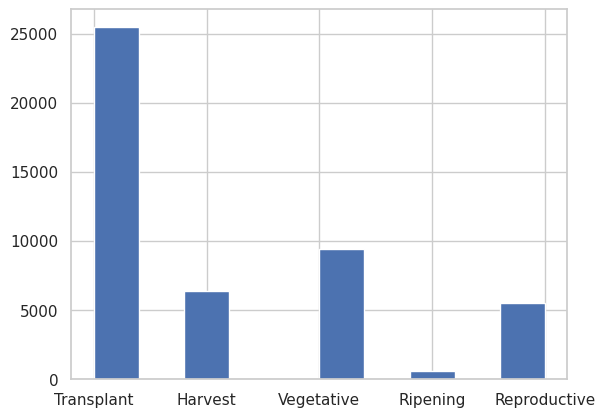

In [329]:
df['stage_name'].hist()

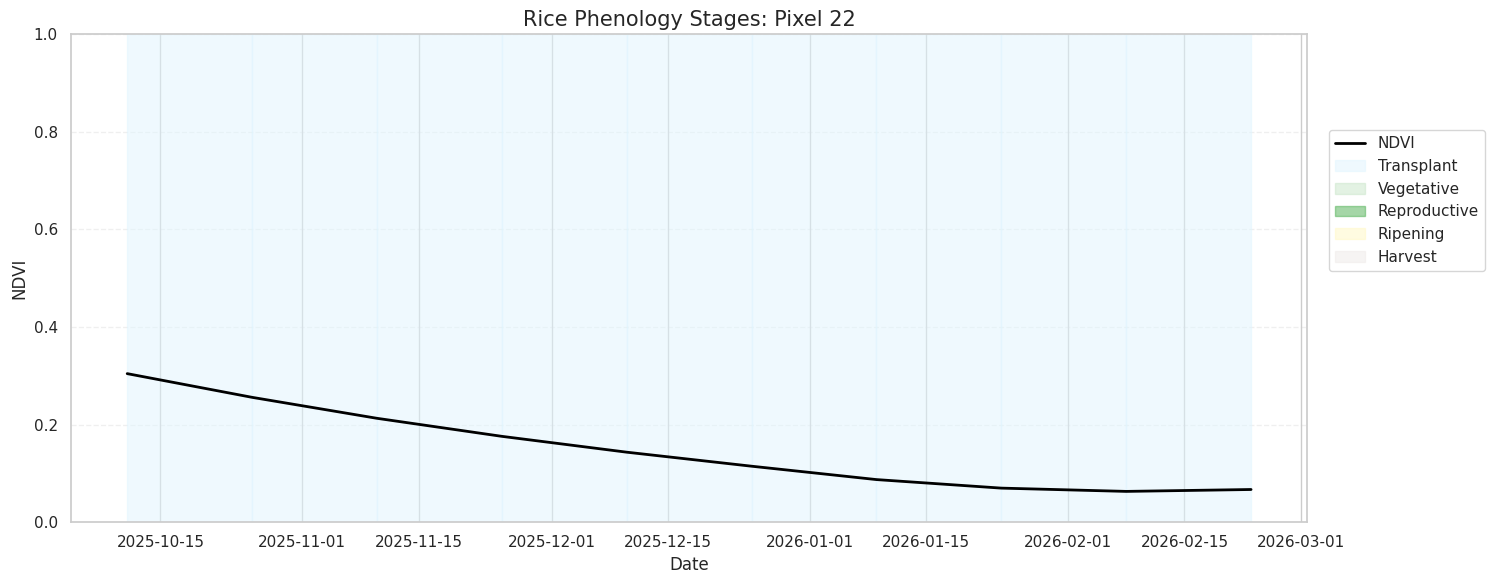

In [330]:
def plot_pixel_stage_progression(df, pixel_id):
    """
    Plots the NDVI curve for a specific pixel and color-codes the background by stage.
    """
    pixel_data = df[df['pixel_id'] == pixel_id].sort_values('ten_day_start')
    
    plt.figure(figsize=(15, 6))
    
    # Define colors for stages
    stage_colors = {
        'Transplant': '#e1f5fe',   # Light Blue
        'Vegetative': '#c8e6c9',   # Light Green
        'Reproductive': '#4caf50', # Dark Green
        'Ripening': '#fff9c4',     # Light Yellow
        'Harvest': '#efebe9'       # Grey/Brown
    }
    
    # 1. Plot the NDVI line
    plt.plot(pixel_data['ten_day_start'], pixel_data['NDVI_median_smooth'], 
             color='black', linewidth=2, label='NDVI (Smoothed)', zorder=5)
    
    # 2. Add colored spans for each stage
    # We find where stages change to create the spans
    pixel_data = pixel_data.reset_index()
    for i in range(len(pixel_data) - 1):
        start_time = pixel_data.loc[i, 'ten_day_start']
        end_time = pixel_data.loc[i+1, 'ten_day_start']
        stage = pixel_data.loc[i, 'stage_name']
        
        plt.axvspan(start_time, end_time, color=stage_colors.get(stage, 'white'), alpha=0.5)

    # 3. Mark the Peak (Reproductive)
    peak_row = pixel_data[pixel_data['stage_name'] == 2]
    if not peak_row.empty:
        max_idx = peak_row['NDVI_median_smooth'].idxmax()
        plt.scatter(pixel_data.loc[max_idx, 'ten_day_start'], 
                    pixel_data.loc[max_idx, 'NDVI_median_smooth'], 
                    color='red', s=100, label='Peak (Reproductive)', zorder=10)

    # Formatting
    plt.title(f"Rice Phenology Stages: Pixel {pixel_id}", fontsize=15)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("NDVI", fontsize=12)
    plt.ylim(0, 1)
    
    # Create custom legend for stages
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color='black', lw=2, label='NDVI')]
    for stage, color in stage_colors.items():
        legend_elements.append(plt.Rectangle((0,0),1,1, color=color, label=stage, alpha=0.5))
    
    plt.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(1.15, 0.5))
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_pixel_stage_progression(df, pixel_id=df['pixel_id'].iloc[0])

/tmp/ipykernel_55/1920393558.py:57: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


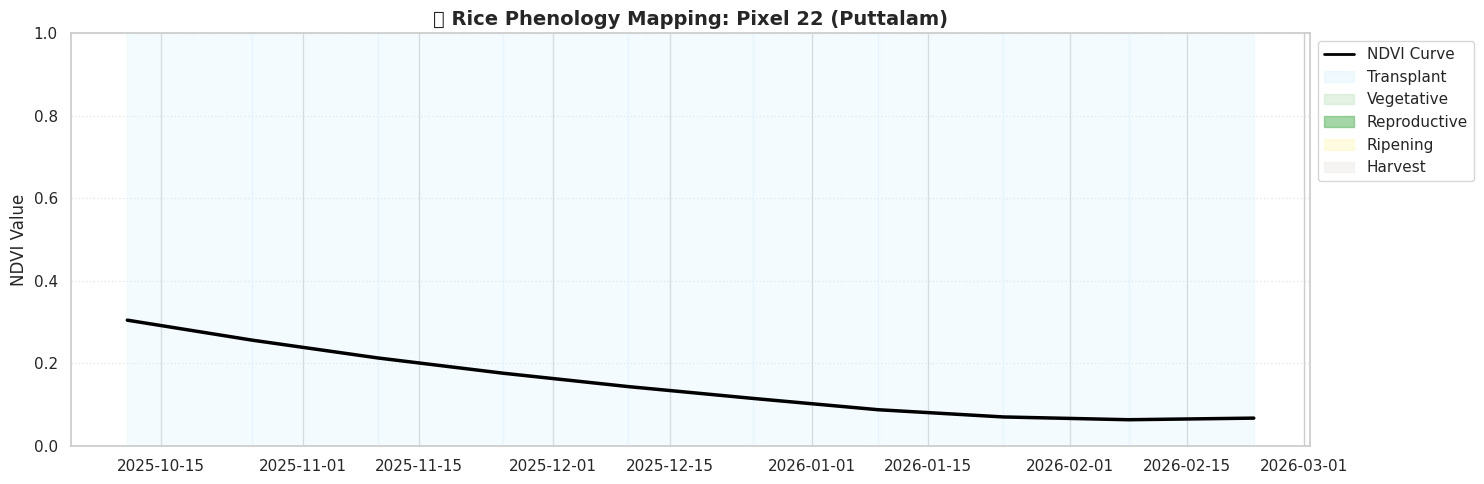

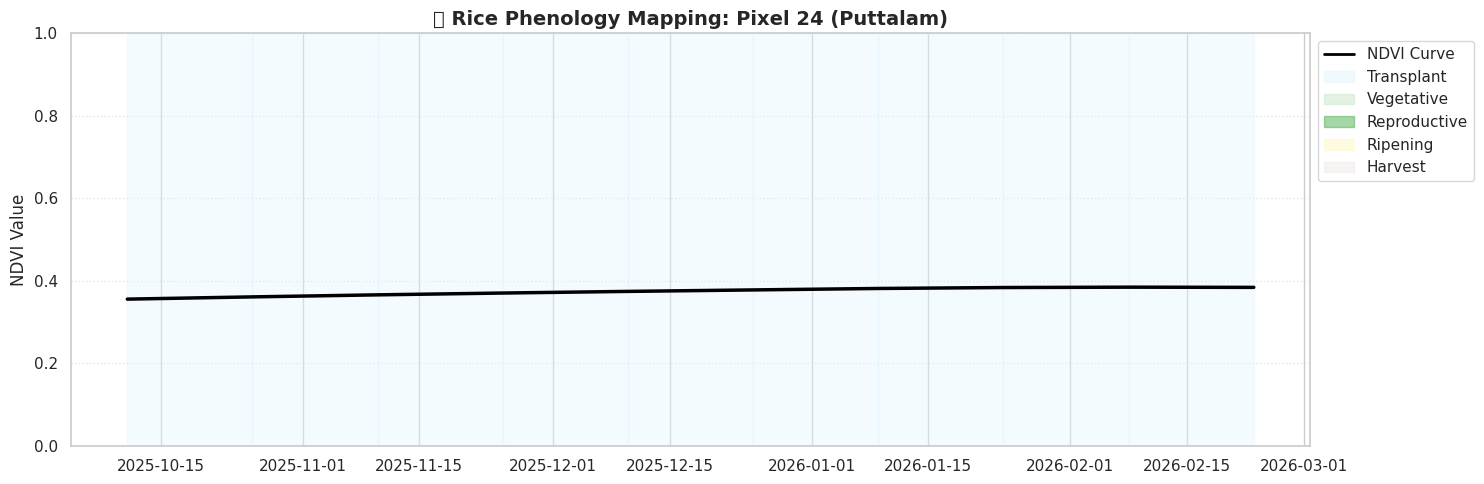

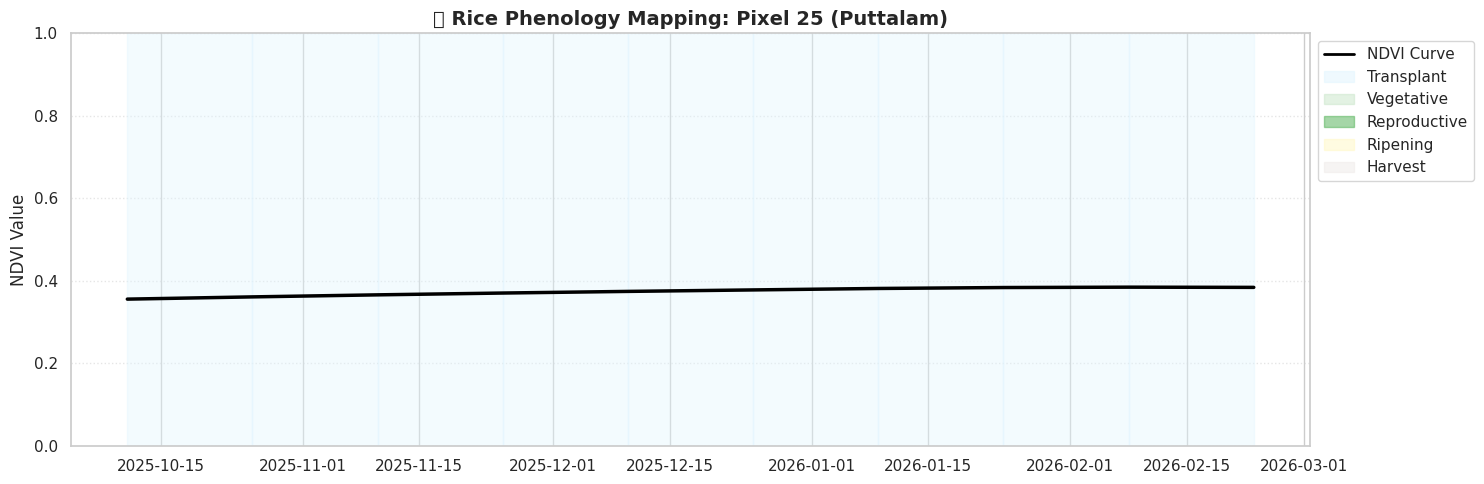

In [331]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_multi_pixel_progression(df, num_pixels=3):
    """
    Selects unique pixels and plots their stage progression.
    """
    # 1. Get unique pixel IDs
    unique_ids = df['pixel_id'].unique()[:num_pixels]
    
    # 2. Define colors for stages (Matching your logic)
    stage_colors = {
        'Transplant': '#e1f5fe',   # Light Blue
        'Vegetative': '#c8e6c9',   # Light Green
        'Reproductive': '#4caf50', # Dark Green
        'Ripening': '#fff9c4',     # Light Yellow
        'Harvest': '#efebe9'       # Grey/Brown
    }

    for pixel_id in unique_ids:
        pixel_data = df[df['pixel_id'] == pixel_id].sort_values('ten_day_start').reset_index(drop=True)
        
        plt.figure(figsize=(15, 5))
        
        # Plot the Smoothed NDVI line
        plt.plot(pixel_data['ten_day_start'], pixel_data['NDVI_median_smooth'], 
                 color='black', linewidth=2.5, label='NDVI (Smoothed)', zorder=5)
        
        # Add background colored spans for each stage
        for i in range(len(pixel_data) - 1):
            start_time = pixel_data.loc[i, 'ten_day_start']
            end_time = pixel_data.loc[i+1, 'ten_day_start']
            stage = pixel_data.loc[i, 'stage_name']
            plt.axvspan(start_time, end_time, color=stage_colors.get(stage, 'white'), alpha=0.4)

        # Mark the actual Peak (Maximum NDVI value during the 'Reproductive' phase)
        repro_phase = pixel_data[pixel_data['stage_name'] == 'Reproductive']
        if not repro_phase.empty:
            peak_idx = repro_phase['NDVI_median_smooth'].idxmax()
            plt.scatter(pixel_data.loc[peak_idx, 'ten_day_start'], 
                        pixel_data.loc[peak_idx, 'NDVI_median_smooth'], 
                        color='red', edgecolor='white', s=120, label='Biological Peak', zorder=10)

        # Styling
        plt.title(f"🌾 Rice Phenology Mapping: Pixel {pixel_id} ({pixel_data['district'].iloc[0]})", 
                  fontsize=14, fontweight='bold')
        plt.ylabel("NDVI Value")
        plt.ylim(0, 1)
        plt.grid(axis='y', linestyle=':', alpha=0.5)

        # Custom Legend
        legend_elements = [Line2D([0], [0], color='black', lw=2, label='NDVI Curve')]
        for stage, color in stage_colors.items():
            legend_elements.append(plt.Rectangle((0,0),1,1, color=color, label=stage, alpha=0.5))
        
        plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))
        plt.tight_layout()
        plt.show()

# Run the plot for 3 unique pixels
plot_multi_pixel_progression(df, num_pixels=3)

# ndvi_zscore

In [332]:
baseline_df = pd.read_csv("/kaggle/input/datasets/sanilawijesekara/sl-baselines/sri_lanka_district_baselines.csv")
# Assuming you have already run map_pixels_to_districts and infer_stage_statistically
def add_district_zscore(df, baseline_df):
    # Merge current data with the historical mean/std for that district and stage
    df = df.merge(
        baseline_df[['district', 'stage_name', 'ndvi_mean', 'ndvi_std']], 
        on=['district', 'stage_name'], 
        how='left'
    )
    
    # Formula: (Current Smoothed NDVI - Historical Mean) / Historical Std
    df['ndvi_zscore'] = (df['NDVI_median_smooth'] - df['ndvi_mean']) / df['ndvi_std']
    
    # Optional: Fill missing values (if a district/stage combo is missing) and clip outliers
    df['ndvi_zscore'] = df['ndvi_zscore'].fillna(0).clip(-3, 3)
    
    return df
df = add_district_zscore(df, baseline_df)

In [333]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47190 entries, 0 to 47189
Data columns (total 82 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   NDVI_median           47190 non-null  float32       
 1   EVI_median            47190 non-null  float32       
 2   EVI2_median           47190 non-null  float32       
 3   LSWI_median           47190 non-null  float32       
 4   NDWI_median           47190 non-null  float32       
 5   GLI_median            47190 non-null  float32       
 6   GCI_median            47190 non-null  float32       
 7   CVI_median            47190 non-null  float32       
 8   SIPI_median           47190 non-null  float32       
 9   RENDVI_median         47190 non-null  float32       
 10  RECI_median           47190 non-null  float32       
 11  CCCI_median           47190 non-null  float32       
 12  S2REP_median          47190 non-null  float32       
 13  BSI_median      

In [334]:
df['ndvi_zscore']

0       -0.769299
1       -1.216979
2       -1.613124
3       -1.953792
4       -2.253043
           ...   
47185    0.504541
47186    1.082431
47187    0.562632
47188    0.786923
47189    0.683153
Name: ndvi_zscore, Length: 47190, dtype: float64

<Axes: >

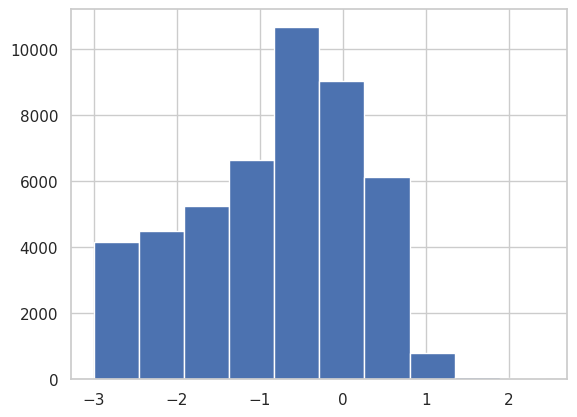

In [335]:
df['ndvi_zscore'].hist()

# Velocities and cpi

In [336]:
# Step B: Get Cohort Health (Your CPI Logic)
if df['pixel_id'].nunique() > 10:
    # We use a safety wrapper for the robust Z to handle tiny groups
    def safe_robust_z(x):
        if len(x) < 5: return np.zeros(len(x)) # Not enough peers for a cohort
        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        iqr = q3 - q1
        denom = max(iqr, 0.05) 
        return (x - x.median()) / denom

    groups = df.groupby(['ten_day_start', 'stage_name'])
    
    df['ndvi_vel_z'] = groups['ndvi_vel'].transform(safe_robust_z)
    df['bsi_z'] = groups['BSI_median_smooth'].transform(safe_robust_z)
    df['lswi_vel_z'] = groups['lswi_vel'].transform(safe_robust_z)

    # Calculate CPI
    df['cpi'] = (
        (df['ndvi_vel_z'] * -1.0) + 
        (df['bsi_z'] * 0.8) + 
        (df['lswi_vel_z'] * -0.6)
    )
else:
    # Single-pixel or small batch mode
    df['CPI'] = 0
    df['ndvi_vel_z'] = 0 
    # Note: ndvi_zscore still works because it's based on the CSV!

In [337]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47190 entries, 0 to 47189
Data columns (total 86 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   NDVI_median           47190 non-null  float32       
 1   EVI_median            47190 non-null  float32       
 2   EVI2_median           47190 non-null  float32       
 3   LSWI_median           47190 non-null  float32       
 4   NDWI_median           47190 non-null  float32       
 5   GLI_median            47190 non-null  float32       
 6   GCI_median            47190 non-null  float32       
 7   CVI_median            47190 non-null  float32       
 8   SIPI_median           47190 non-null  float32       
 9   RENDVI_median         47190 non-null  float32       
 10  RECI_median           47190 non-null  float32       
 11  CCCI_median           47190 non-null  float32       
 12  S2REP_median          47190 non-null  float32       
 13  BSI_median      

/tmp/ipykernel_55/4257102453.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='stage_name', order=present_stages, palette='magma')


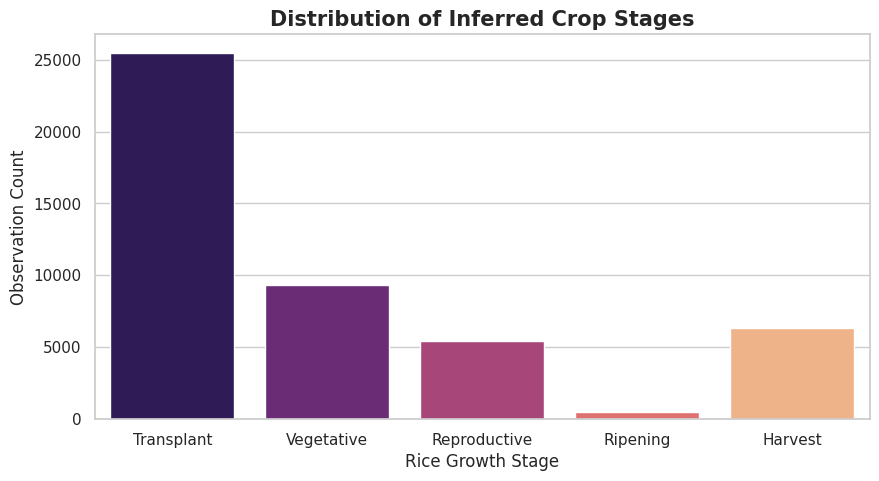

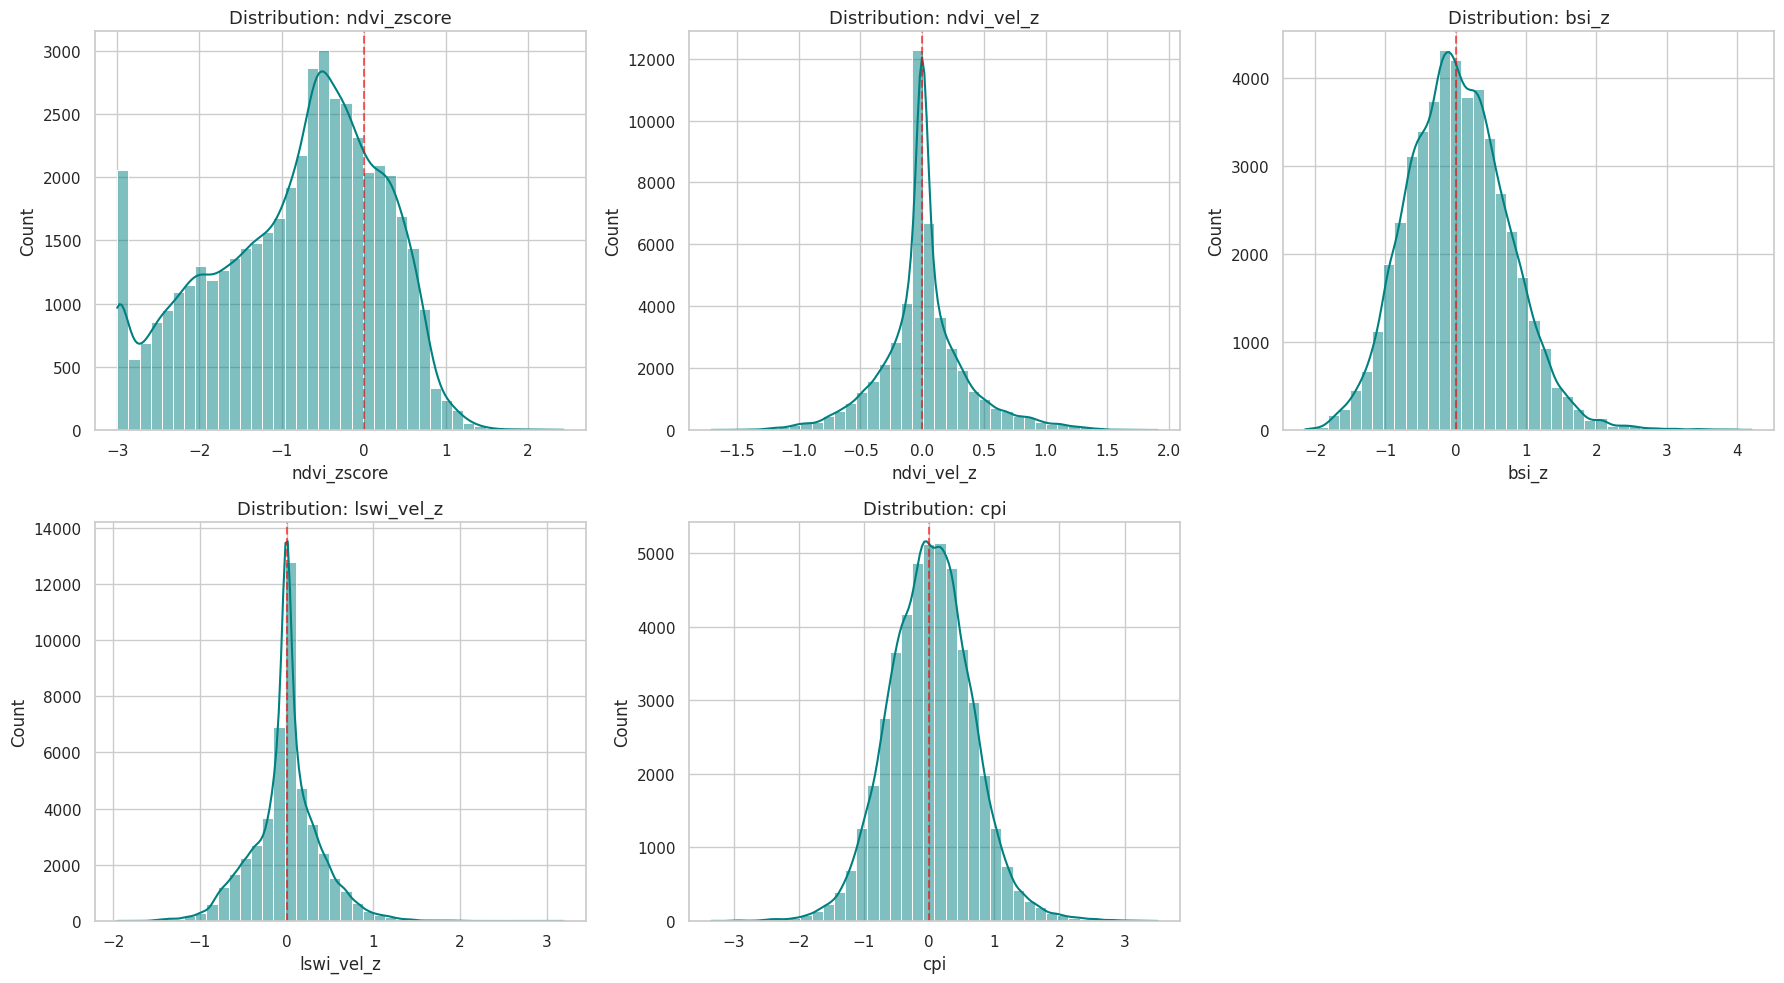

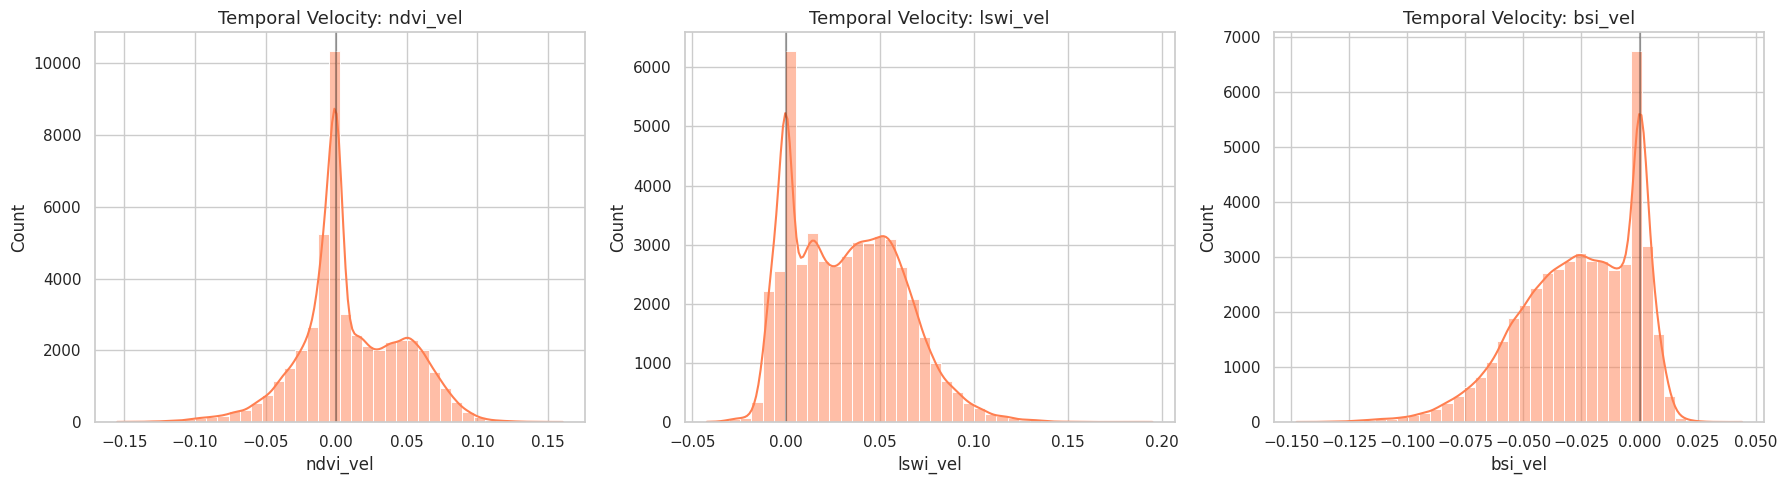

In [339]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_inference_distributions(df):
    # Set visual theme
    sns.set_theme(style="whitegrid")
    
    # --- 1. Growth Stage Distribution ---
    plt.figure(figsize=(10, 5))
    # Order them chronologically for the plot
    stage_order = ['Transplant', 'Vegetative', 'Reproductive', 'Ripening', 'Harvest']
    present_stages = [s for s in stage_order if s in df['stage_name'].unique()]
    
    sns.countplot(data=df, x='stage_name', order=present_stages, palette='magma')
    plt.title('Distribution of Inferred Crop Stages', fontsize=15, fontweight='bold')
    plt.xlabel('Rice Growth Stage')
    plt.ylabel('Observation Count')
    plt.show()

    # --- 2. Health & Stress Indicators (Z-Scores & CPI) ---
    # These should ideally look like Bell Curves centered near 0
    health_features = ['ndvi_zscore', 'ndvi_vel_z', 'bsi_z', 'lswi_vel_z', 'cpi']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(health_features):
        sns.histplot(df[col], kde=True, ax=axes[i], color='teal', bins=40)
        axes[i].set_title(f'Distribution: {col}', fontsize=13)
        axes[i].axvline(0, color='red', linestyle='--', alpha=0.6) # Reference line at 0
        
    # Remove the empty 6th subplot
    fig.delaxes(axes[5])
    plt.tight_layout()
    plt.show()

    # --- 3. Momentum Features (Velocities) ---
    vel_features = ['ndvi_vel', 'lswi_vel', 'bsi_vel']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for i, col in enumerate(vel_features):
        sns.histplot(df[col], kde=True, ax=axes[i], color='coral', bins=40)
        axes[i].set_title(f'Temporal Velocity: {col}', fontsize=13)
        axes[i].axvline(0, color='black', linestyle='-', alpha=0.3)
        
    plt.tight_layout()
    plt.show()

# Execute the plotting
plot_inference_distributions(df)

In [340]:
df.head()

,NDVI_median,EVI_median,EVI2_median,LSWI_median,NDWI_median,GLI_median,GCI_median,CVI_median,SIPI_median,RENDVI_median,...,lswi_vel,bsi_vel,stage_name,ndvi_mean,ndvi_std,ndvi_zscore,ndvi_vel_z,bsi_z,lswi_vel_z,cpi
0,0.304838,0.354223,0.272705,0.019995,0.069238,0.028234,0.896762,1.916677,1.147661,0.144434,...,0.000000,0.000000,Transplant,0.388073,0.108505,-0.769299,0.000000,-0.500710,0.000000,-0.400568
1,0.255540,0.342954,0.239791,0.053443,0.044081,0.020743,0.689284,1.692043,1.122990,0.117268,...,0.033444,-0.026720,Transplant,0.388073,0.108505,-1.216979,-0.618742,-0.333663,-0.228687,0.489024
2,0.213069,0.330013,0.208737,0.086460,0.025714,0.015200,0.533803,1.526116,1.092581,0.093728,...,0.033021,-0.024041,Transplant,0.388073,0.108505,-1.613124,-0.459750,-0.120219,-0.253556,0.515708
3,0.176097,0.314998,0.179391,0.119055,0.011715,0.010934,0.412948,1.398569,1.054166,0.073133,...,0.032594,-0.021187,Transplant,0.388073,0.108505,-1.953792,-0.343846,0.079133,-0.235529,0.548470
4,0.143621,0.297367,0.151614,0.151234,0.000691,0.007548,0.316312,1.297479,1.004108,0.054963,...,0.032179,-0.018959,Transplant,0.388073,0.108505,-2.253043,-0.279155,0.275905,-0.226791,0.635954


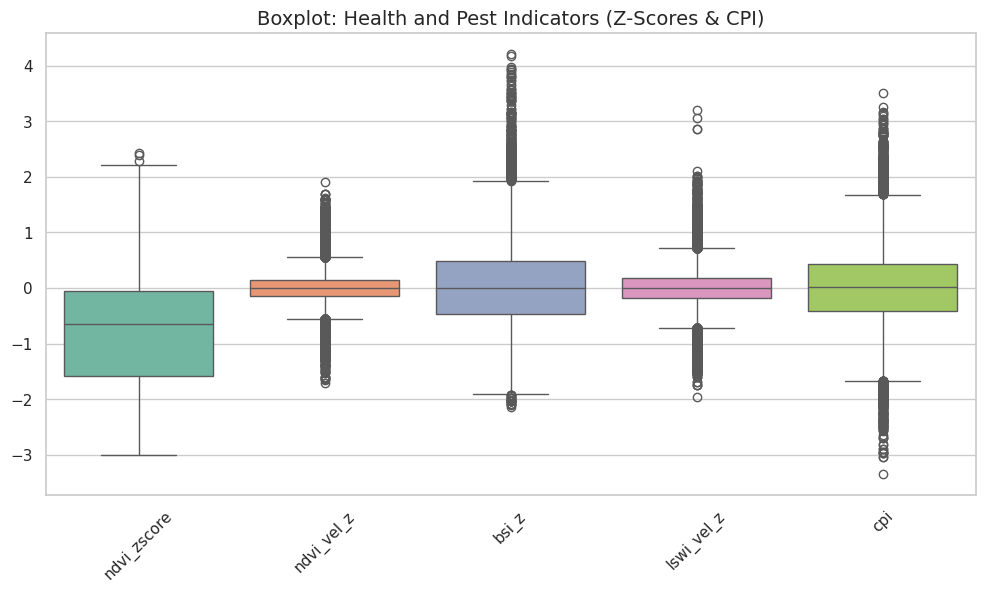

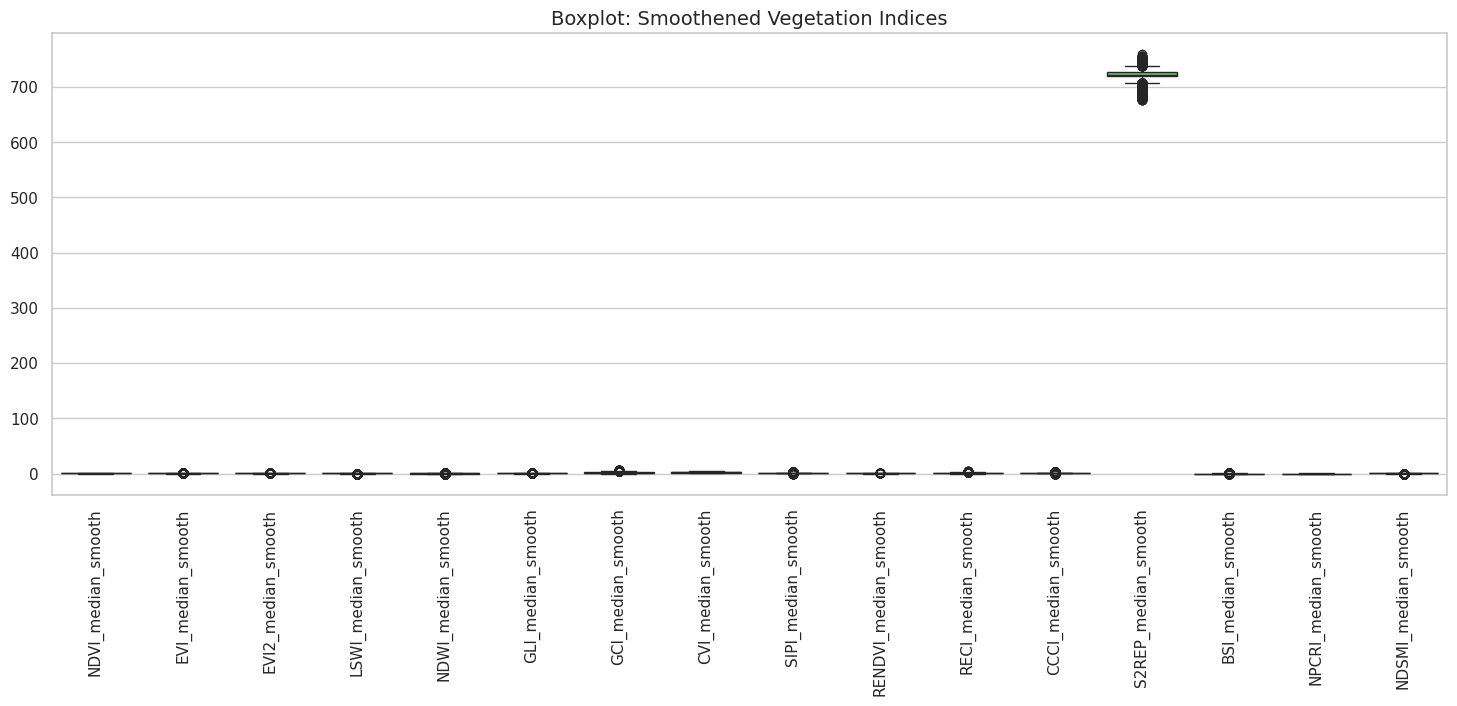

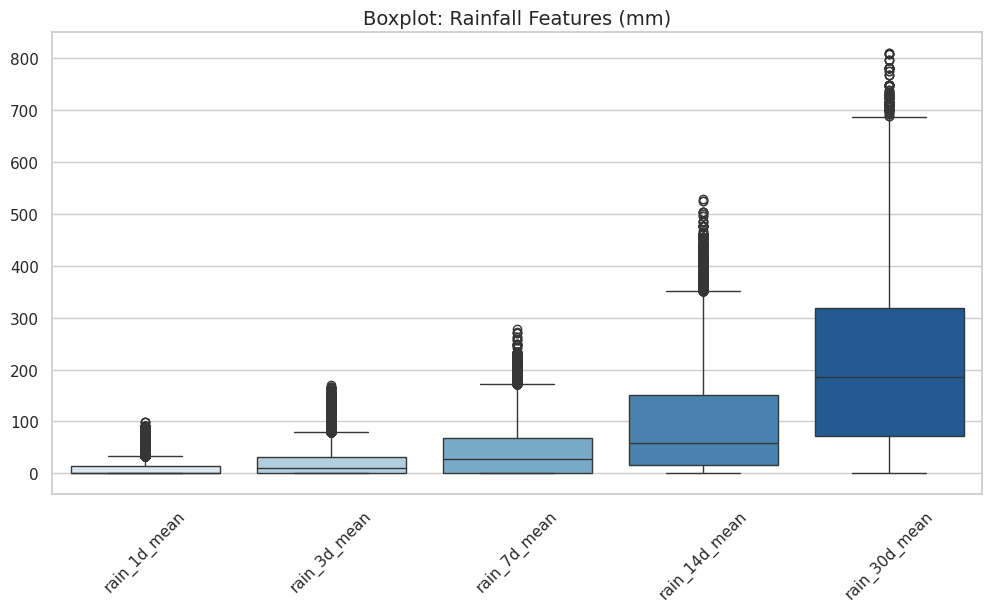

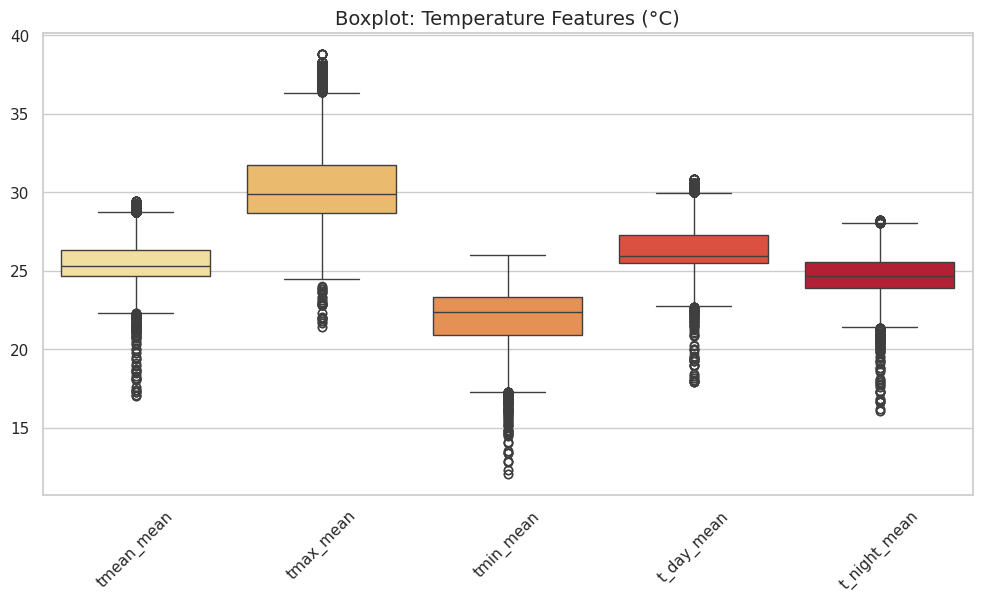

In [342]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_boxplots(df):
    sns.set_theme(style="whitegrid")
    
    # Define feature groups
    health_cols = ['ndvi_zscore', 'ndvi_vel_z', 'bsi_z', 'lswi_vel_z', 'cpi']
    
    smooth_cols = [col for col in df.columns if col.endswith('_smooth')]
    
    weather_rain = [col for col in df.columns if 'rain' in col]
    weather_temp = [col for col in df.columns if col.startswith('t') and 'mean' in col and 'rain' not in col]

    # --- Plot 1: Health & Stress Indices ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[health_cols], palette="Set2")
    plt.title("Boxplot: Health and Pest Indicators (Z-Scores & CPI)", fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

    # --- Plot 2: Smoothened Vegetation Indices ---
    plt.figure(figsize=(18, 6))
    sns.boxplot(data=df[smooth_cols], palette="viridis")
    plt.title("Boxplot: Smoothened Vegetation Indices", fontsize=14)
    plt.xticks(rotation=90)
    plt.show()

    # --- Plot 3: Weather Features (Rainfall) ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[weather_rain], palette="Blues")
    plt.title("Boxplot: Rainfall Features (mm)", fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

    # --- Plot 4: Weather Features (Temperature) ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[weather_temp], palette="YlOrRd")
    plt.title("Boxplot: Temperature Features (°C)", fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

# Run the plotting function
plot_feature_boxplots(df)

⚠️ Warning: Significant bias detected in the following districts/stages:
      district    stage_name  ndvi_zscore
46     Kegalle    Transplant    -3.000000
47     Kegalle    Vegetative    -3.000000
104   Vavuniya    Vegetative    -3.000000
19     Colombo    Transplant    -2.895083
28     Gampaha    Transplant    -2.389313
..         ...           ...          ...
22       Galle  Reproductive     0.441530
17     Colombo       Harvest     0.459916
66      Matara  Reproductive     0.542115
92   Ratnapura  Reproductive     0.721345
18     Colombo  Reproductive     1.245566

[71 rows x 3 columns]


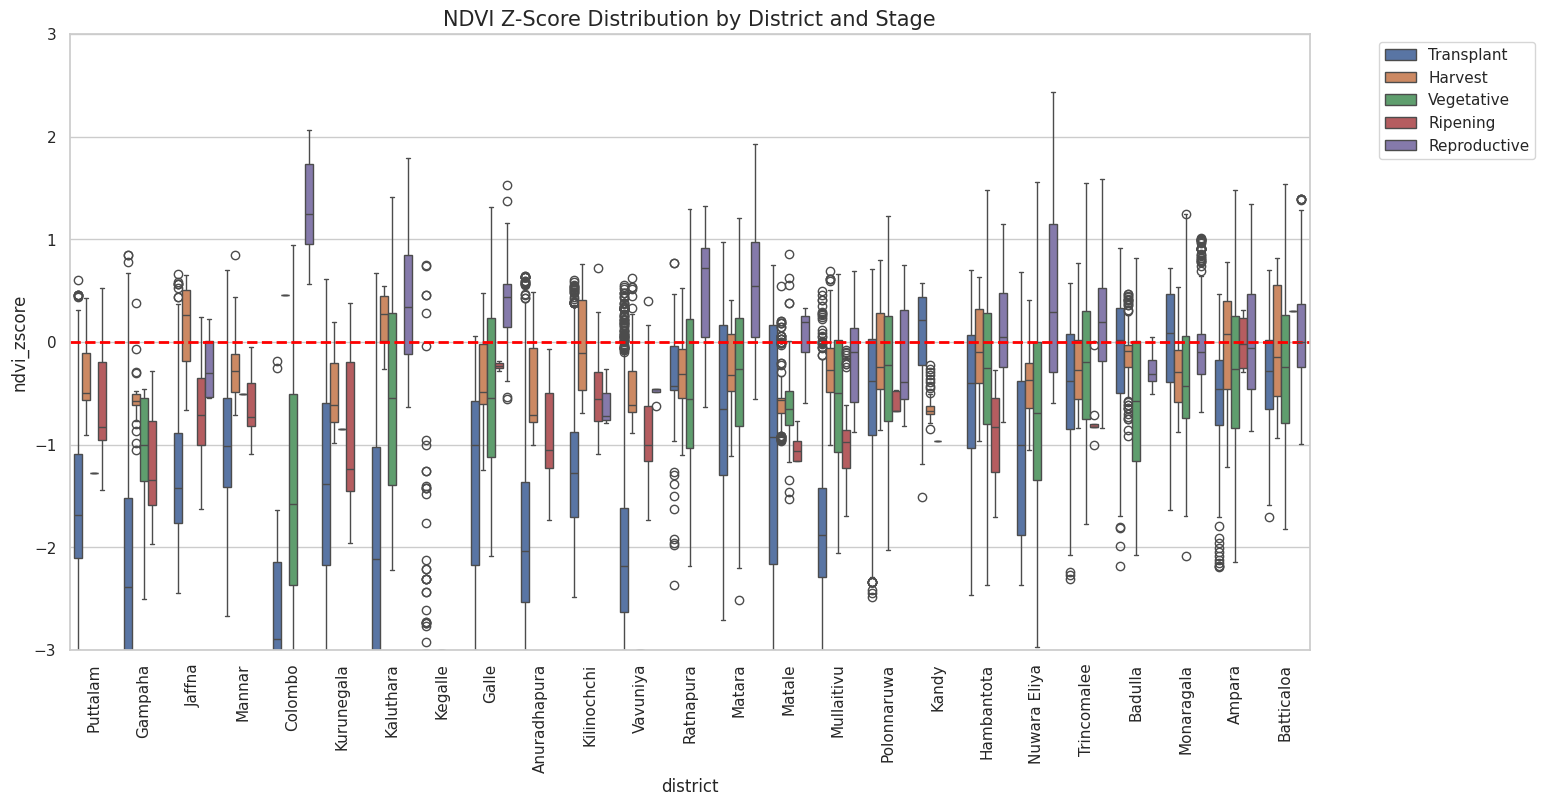

In [343]:
def check_district_bias(df):
    # Calculate median z-score per district and stage
    bias_report = df.groupby(['district', 'stage_name'])['ndvi_zscore'].median().reset_index()
    
    # Identify "Strong Bias" (where median is > 0.3 or < -0.3)
    # A perfect baseline should result in a median of 0.0
    strong_bias = bias_report[bias_report['ndvi_zscore'].abs() > 0.3].sort_values(by='ndvi_zscore')
    
    if strong_bias.empty:
        print("✅ No significant district bias detected. Baselines are well-calibrated.")
    else:
        print("⚠️ Warning: Significant bias detected in the following districts/stages:")
        print(strong_bias)
        
    # Visual check using a FacetGrid Boxplot
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(16, 8))
    sns.boxplot(data=df, x='district', y='ndvi_zscore', hue='stage_name')
    plt.axhline(0, color='red', linestyle='--', linewidth=2)
    plt.title("NDVI Z-Score Distribution by District and Stage", fontsize=15)
    plt.xticks(rotation=90)
    plt.ylim(-3, 3) # Zoom in on the core distribution
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()
    
    return bias_report

bias_df = check_district_bias(df)

# Season

In [344]:
# 2. Extract the month
df['month'] = df['ten_day_start'].dt.month

# 3. Define the season logic
# If month is between 4 (April) and 8 (August), it's Yala. Otherwise, it's Maha.
df['season'] = np.where(df['month'].isin([4, 5, 6, 7, 8]), 'Yala', 'Maha')

# Example check:
# A date like '2022-01-15' has month 1, which will be assigned 'Maha'
print(df[['ten_day_start', 'month', 'season']].head())

  ten_day_start  month season
0    2025-10-11     10   Maha
1    2025-10-26     10   Maha
2    2025-11-10     11   Maha
3    2025-11-25     11   Maha
4    2025-12-10     12   Maha


In [345]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47190 entries, 0 to 47189
Data columns (total 87 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   NDVI_median           47190 non-null  float32       
 1   EVI_median            47190 non-null  float32       
 2   EVI2_median           47190 non-null  float32       
 3   LSWI_median           47190 non-null  float32       
 4   NDWI_median           47190 non-null  float32       
 5   GLI_median            47190 non-null  float32       
 6   GCI_median            47190 non-null  float32       
 7   CVI_median            47190 non-null  float32       
 8   SIPI_median           47190 non-null  float32       
 9   RENDVI_median         47190 non-null  float32       
 10  RECI_median           47190 non-null  float32       
 11  CCCI_median           47190 non-null  float32       
 12  S2REP_median          47190 non-null  float32       
 13  BSI_median      

<Axes: >

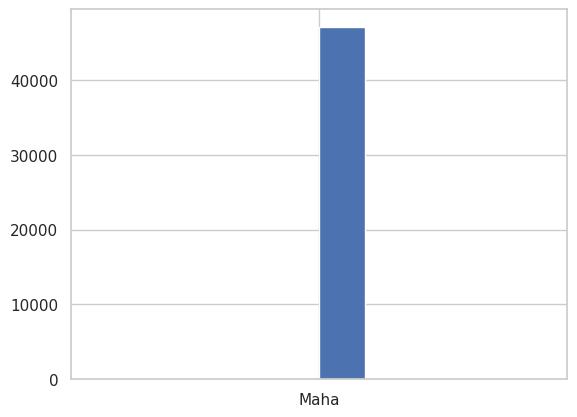

In [346]:
df['season'].hist()

# Remove unnecessary columns

In [347]:
import pandas as pd

# 1. Define the target columns from your 66-column list
target_cols = [
    'pixel_id', 'year', 'date', 'rain_1d_mean', 'rain_3d_mean', 'rain_7d_mean', 
    'rain_14d_mean', 'rain_30d_mean', 'tmean_mean', 'tmax_mean', 'tmin_mean', 
    't_day_mean', 't_night_mean', 'rh_mean_mean', 'lat', 'lon', 'elevation', 
    'slope', 'ten_day_start', 'delta_days', 'doy', 'doy_sin', 'doy_cos', 
    'ndvi_median_smooth', 'evi_median_smooth', 'evi2_median_smooth', 
    'lswi_median_smooth', 'ndwi_median_smooth', 'gli_median_smooth', 
    'gci_median_smooth', 'cvi_median_smooth', 'sipi_median_smooth', 
    'rendvi_median_smooth', 'reci_median_smooth', 'ccci_median_smooth', 
    's2rep_median_smooth', 'bsi_median_smooth', 'npcri_median_smooth', 
    'ndsmi_median_smooth', 'stage_name', 'ndvi_zscore', 'ndvi_vel', 
    'lswi_vel', 'bsi_vel', 'ndvi_vel_z', 'bsi_z', 'lswi_vel_z', 'cpi', 
    'month', 'season', 'district'
]

# 2. Rename existing columns to lowercase to match the target list
# (Handles cases like 'CPI' -> 'cpi' and 'NDVI_median_smooth' -> 'ndvi_median_smooth')
df.columns = [col.lower() for col in df.columns]

# 3. Drop bands and raw medians (already effectively done by selecting target_cols)
# We select only the columns that exist in both our DataFrame and the target list
existing_target_cols = [col for col in target_cols if col in df.columns]

df_final = df[existing_target_cols].copy()

# 4. Optional: If you need to add the 'stage' (integer) column from 'stage_name'
stage_mapping = {
    'Transplant': 0, 
    'Vegetative': 1, 
    'Reproductive': 2, 
    'Ripening': 3, 
    'Harvest': 4
}
if 'stage_name' in df_final.columns:
    df_final['stage'] = df_final['stage_name'].map(stage_mapping)

# Check the results
print(df_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47190 entries, 0 to 47189
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   pixel_id              47190 non-null  int64         
 1   year                  47190 non-null  int32         
 2   date                  47190 non-null  datetime64[ns]
 3   rain_1d_mean          47190 non-null  float64       
 4   rain_3d_mean          47190 non-null  float64       
 5   rain_7d_mean          47190 non-null  float64       
 6   rain_14d_mean         47190 non-null  float64       
 7   rain_30d_mean         47190 non-null  float64       
 8   tmean_mean            47190 non-null  float64       
 9   tmax_mean             47190 non-null  float64       
 10  tmin_mean             47190 non-null  float64       
 11  t_day_mean            47190 non-null  float64       
 12  t_night_mean          47190 non-null  float64       
 13  rh_mean_mean    